# Seasonal Agriculture Performance Analysis

**VOIS / AICTE Batch 1 (2026–2027) — Major Project**

| | |
|---|---|
| **Student** | *Shivani Chaudhary* |
| **College** | *BITS Goa* |
| **AICTE Student ID** | *STU6a6a3b03e36e41785346819* |
| **Course** | Data Visualization and Data Analytics |
| **Dataset** | `seasonal_agriculture_performance_dataset.csv` — 4,000 farm records × 28 columns |

---

## Problem statement

> Agricultural activities are influenced by seasonal variations in environmental conditions, farming
> practices, resource availability and market conditions. As a result, agricultural performance may
> differ from one season to another. However, raw agricultural data does not clearly explain **how**
> agricultural performance changes across seasons or what patterns can be observed in different
> seasonal conditions. The problem is to analyse the given agricultural dataset and investigate
> seasonal differences in agricultural performance by identifying meaningful patterns, trends,
> relationships and variations within the available data.

## Objective

Analyse farm-level agricultural data from the three Indian cropping seasons — **Kharif** (monsoon),
**Rabi** (winter) and **Zaid** (summer) — and identify meaningful patterns, trends, relationships and
differences in agricultural performance, then convert those findings into evidence-based
recommendations for seasonal agricultural planning.

## The eight analytical questions this notebook answers

| # | Question | Section |
|---|---|---|
| **Q1** | Is the dataset internally consistent, and what must be cleaned before analysis? | 3–4 |
| **Q2** | What is the *environmental signature* of each season? | 6 |
| **Q3** | Does agricultural **productivity** differ across seasons — and is the difference statistically real? | 7 |
| **Q4** | Is the seasonal ranking **robust**, or an artefact of crop / region mix? | 8 |
| **Q5** | Which environmental conditions **drive** the seasonal yield gap? | 9 |
| **Q6** | How does **resource usage and water efficiency** vary across seasons? | 10 |
| **Q7** | How do **economic outcomes** vary across seasons, and why? | 11 |
| **Q8** | Can a model **quantify** the drivers, and how much do they explain? | 12 |

## Notebook roadmap

`Setup` → `Load & first look` → `Data-quality audit` → `Cleaning & feature engineering` →
`Season profiles` → `Productivity` → `Robustness` → `Environmental drivers` →
`Resource efficiency` → `Economics` → `Modelling` → `Statistical summary` →
`Findings, recommendations & limitations`

---
# 1. Setup

A single, validated colour system is used throughout so that a season always keeps the same colour.
The three season hues come from a categorical palette that was checked with a colour-vision-deficiency
validator: the worst all-pairs separation is ΔE 9.2 (deuteranopia), comfortably above the ΔE ≥ 8
target, so the chart stays readable for red–green colour-blind readers.

In [1]:
import warnings, textwrap
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', lambda v: f'{v:,.3f}')

DATA_DIR = Path('data')
FIG_DIR  = Path('figures');  FIG_DIR.mkdir(exist_ok=True)
OUT_DIR  = Path('outputs');  OUT_DIR.mkdir(exist_ok=True)

# ---- design tokens -------------------------------------------------------
SURFACE   = '#fcfcfb'
INK       = '#0b0b0b'
INK_2     = '#52514e'
INK_MUTED = '#8a8985'
GRID      = '#e7e6e2'

SEASON_ORDER  = ['Kharif', 'Rabi', 'Zaid']
SEASON_COLOR  = {'Kharif': '#1baf7a',   # aqua  - monsoon
                 'Rabi'  : '#2a78d6',   # blue  - winter
                 'Zaid'  : '#eb6834'}   # orange- summer
SEASON_LABEL  = {'Kharif': 'Kharif (monsoon)',
                 'Rabi'  : 'Rabi (winter)',
                 'Zaid'  : 'Zaid (summer)'}
ACCENT   = '#2a78d6'
NEGATIVE = '#e34948'
POSITIVE = '#1baf7a'
SEQ_BLUE = ['#cde2fb', '#9ec5f4', '#6da7ec', '#3987e5', '#256abf', '#184f95', '#0d366b']

mpl.rcParams.update({
    'figure.facecolor' : SURFACE,  'axes.facecolor'   : SURFACE,
    'savefig.facecolor': SURFACE,  'savefig.dpi'      : 200,
    'figure.dpi'       : 72,       'savefig.bbox'     : 'tight',   # inline size; PNG exports stay at 200
    'font.family'      : 'DejaVu Sans',
    'font.size'        : 10.5,
    'text.color'       : INK,      'axes.labelcolor'  : INK_2,
    'xtick.color'      : INK_2,    'ytick.color'      : INK_2,
    'axes.titlesize'   : 13,       'axes.titleweight' : 'bold',
    'axes.titlecolor'  : INK,      'axes.titlelocation': 'left',
    'axes.titlepad'    : 10,       'axes.labelsize'   : 10,
    'axes.edgecolor'   : GRID,     'axes.linewidth'   : 0.8,
    'axes.spines.top'  : False,    'axes.spines.right': False,
    'grid.color'       : GRID,     'grid.linewidth'   : 0.8,
    'grid.linestyle'   : '-',      'legend.frameon'   : False,
    'legend.fontsize'  : 9.5,      'xtick.major.size' : 0,
    'ytick.major.size' : 0,
})

def style(ax, xgrid=False, ygrid=True):
    '''Recessive hairline grid, no chartjunk.'''
    ax.set_axisbelow(True)
    ax.grid(axis='y', visible=ygrid); ax.grid(axis='x', visible=xgrid)
    ax.tick_params(length=0)
    return ax

def save(fig, name):
    '''Save a figure for reuse in the presentation.'''
    p = FIG_DIR / f'{name}.png'
    fig.savefig(p)
    print(f'  saved -> {p}')
    return p

inr  = FuncFormatter(lambda v, _: f'₹{v:,.0f}')
inrk = FuncFormatter(lambda v, _: f'₹{v/1000:,.0f}k')

print('Environment ready')
print(f'pandas {pd.__version__} | numpy {np.__version__} | '
      f'matplotlib {mpl.__version__} | seaborn {sns.__version__} | scipy {stats.__name__}')

Environment ready
pandas 3.0.5 | numpy 2.5.2 | matplotlib 3.11.1 | seaborn 0.13.2 | scipy scipy.stats


---
# 2. Load the data and take a first look

In [2]:
raw = pd.read_csv(DATA_DIR / 'seasonal_agriculture_performance_dataset.csv')

print(f'Rows      : {raw.shape[0]:,}')
print(f'Columns   : {raw.shape[1]}')
print(f'Memory    : {raw.memory_usage(deep=True).sum()/1e6:.2f} MB')
raw.head()

Rows      : 4,000
Columns   : 28
Memory    : 2.04 MB


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.530,486.400,24.300,69.100,5.800,7.140,32.800,75.800,61.300,91.000,Drip,242.700,4.330,0.760,2.460,1.300,23700,42662,30810,-11852,237,5.485,55.300
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.530,855.400,25.700,78.400,5.100,5.200,32.000,82.100,35.400,121.800,Flood,271.400,6.860,0.940,0.300,1.960,20613,492351,40401,-451950,4953,0.396,49.900
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.860,455.600,23.900,56.400,10.300,5.820,8.100,118.500,51.500,117.900,Drip,162.600,6.080,0.980,0.520,2.530,75283,315210,190466,-124744,1275,1.984,33.700
3,SF10004,Telangana,Indore,Rice,Kharif,4.500,753.200,29.700,65.200,6.300,5.980,23.700,138.600,55.600,115.500,Rainfed,182.200,6.390,0.740,1.840,8.280,24244,296444,200740,-95704,3834,2.160,50.600
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.210,101.600,34.100,55.200,6.500,6.900,29.300,124.100,69.000,121.400,Flood,244.900,7.610,0.900,2.210,9.300,20818,337959,193607,-144352,3287,2.829,32.300


In [3]:
# Column inventory grouped by the role each variable plays in the analysis
groups = {
    'Identity / grouping' : ['Farm_ID', 'State', 'District', 'Crop', 'Season'],
    'Scale'               : ['Farm_Area_Hectares'],
    'Weather'             : ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day'],
    'Soil'                : ['Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha',
                             'Phosphorus_kg_ha', 'Potassium_kg_ha'],
    'Farming practice'    : ['Irrigation_Method', 'Fertilizer_kg_ha',
                             'Pesticide_Litre_ha', 'Seed_Quality_Score'],
    'Output'              : ['Yield_Tonnes_Ha', 'Production_Tonnes'],
    'Economics'           : ['Market_Price_INR_Tonne', 'Total_Cost_INR',
                             'Revenue_INR', 'Profit_INR'],
    'Water'               : ['Water_Used_m3', 'Water_Efficiency_t_per_1000m3'],
    'Risk'                : ['Disease_Pest_Risk_pct'],
}
inventory = pd.DataFrame(
    [(g, c, str(raw[c].dtype), raw[c].nunique(), int(raw[c].isna().sum()))
     for g, cols in groups.items() for c in cols],
    columns=['Role', 'Column', 'Dtype', 'Unique', 'Missing'])
assert len(inventory) == raw.shape[1], 'every column must be classified'
inventory

,Role,Column,Dtype,Unique,Missing
0,Identity / grouping,Farm_ID,str,4000,0
1,Identity / grouping,State,str,8,0
2,Identity / grouping,District,str,10,0
3,Identity / grouping,Crop,str,8,0
4,Identity / grouping,Season,str,3,0
5,Scale,Farm_Area_Hectares,float64,1370,0
6,Weather,Rainfall_mm,float64,3256,48
7,Weather,Avg_Temperature_C,float64,204,0
8,Weather,Humidity_pct,float64,573,0
9,Weather,Sunlight_Hours_Day,float64,71,0


In [4]:
# Categorical levels
for c in ['Season', 'Crop', 'State', 'District', 'Irrigation_Method']:
    vc = raw[c].value_counts()
    print(f'\n{c}  ({raw[c].nunique()} levels)')
    print('  ' + ' | '.join(f'{k}: {v:,}' for k, v in vc.items()))


Season  (3 levels)
  Kharif: 1,779 | Rabi: 1,627 | Zaid: 594

Crop  (8 levels)
  Rice: 690 | Wheat: 614 | Maize: 551 | Cotton: 508 | Pulses: 496 | Groundnut: 424 | Chilli: 412 | Sugarcane: 305

State  (8 levels)
  Andhra Pradesh: 529 | Telangana: 516 | Maharashtra: 512 | Madhya Pradesh: 497 | Karnataka: 489 | Gujarat: 488 | Tamil Nadu: 485 | Punjab: 484

District  (10 levels)
  Ludhiana: 427 | Warangal: 422 | Nalgonda: 415 | Erode: 403 | Rajkot: 401 | Krishna: 393 | Indore: 392 | Guntur: 390 | Raichur: 386 | Nashik: 371

Irrigation_Method  (4 levels)
  Flood: 1,310 | Rainfed: 1,041 | Drip: 915 | Sprinkler: 734


In [5]:
raw.describe().T[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']].round(2)

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,"4,000.000",7.890,4.220,0.500,4.260,7.900,11.650,15.000
Rainfall_mm,"3,952.000",601.150,288.930,80.000,370.200,582.000,834.950,"1,395.200"
Avg_Temperature_C,"4,000.000",26.820,3.820,16.200,23.900,26.900,29.600,39.700
Humidity_pct,"4,000.000",63.210,11.960,25.000,54.780,63.000,71.900,95.000
Sunlight_Hours_Day,"4,000.000",7.320,1.120,3.500,6.600,7.300,8.100,11.000
Soil_pH,"4,000.000",6.700,0.640,5.200,6.260,6.690,7.140,8.400
Soil_Moisture_pct,"3,960.000",26.510,6.710,8.000,21.700,26.400,31.300,47.000
Nitrogen_kg_ha,"4,000.000",120.250,31.220,40.000,98.500,120.100,141.220,220.000
Phosphorus_kg_ha,"4,000.000",57.780,17.020,15.000,46.200,57.500,69.400,120.000
Potassium_kg_ha,"4,000.000",104.760,27.740,30.000,86.200,105.100,123.600,200.000


---
# 3. Data-quality audit  <span style="color:#52514e">(Q1)</span>

Before any comparison is made, four things are checked: **missing values**, **duplicates**,
**internal consistency of the derived columns**, and **plausibility of ranges**. The consistency
check is the important one — the dataset contains several columns that are arithmetic functions of
others, and confirming those identities tells us both that the data is trustworthy *and* how missing
values can be recovered exactly rather than guessed.

In [6]:
# ---- 3.1 missing values --------------------------------------------------
miss = (raw.isna().sum().to_frame('n_missing')
           .assign(pct=lambda d: (d.n_missing / len(raw) * 100).round(2))
           .query('n_missing > 0').sort_values('n_missing', ascending=False))
print('Columns with missing values:\n')
print(miss)
print(f'\nTotal missing cells : {int(raw.isna().sum().sum())} '
      f'({raw.isna().sum().sum()/raw.size*100:.3f}% of all cells)')
print(f'Rows with >=1 missing: {int(raw.isna().any(axis=1).sum())} '
      f'({raw.isna().any(axis=1).mean()*100:.2f}%)')

Columns with missing values:

                   n_missing   pct
Rainfall_mm               48 1.200
Soil_Moisture_pct         40 1.000
Yield_Tonnes_Ha           32 0.800

Total missing cells : 120 (0.107% of all cells)
Rows with >=1 missing: 120 (3.00%)


In [7]:
# Is the missingness related to season? (i.e. is it MCAR or does it bias the comparison?)
print('Missing-rate by season (%):\n')
mrate = (raw.groupby('Season')[['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']]
            .apply(lambda g: g.isna().mean() * 100).round(2)
            .reindex(SEASON_ORDER))
print(mrate)

for col in ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']:
    ct = pd.crosstab(raw.Season, raw[col].isna())
    chi2, p, _, _ = stats.chi2_contingency(ct)
    print(f'  {col:20s} chi2={chi2:5.2f}  p={p:.3f}  '
          f'{"-> not related to season (MCAR-consistent)" if p > .05 else "-> related to season!"}')

Missing-rate by season (%):

        Rainfall_mm  Soil_Moisture_pct  Yield_Tonnes_Ha
Season                                                 
Kharif        1.070              1.010            0.390
Rabi          1.110              0.800            1.230
Zaid          1.850              1.520            0.840
  Rainfall_mm          chi2= 2.51  p=0.285  -> not related to season (MCAR-consistent)
  Soil_Moisture_pct    chi2= 2.26  p=0.323  -> not related to season (MCAR-consistent)
  Yield_Tonnes_Ha      chi2= 7.50  p=0.024  -> related to season!


In [8]:
# ---- 3.2 duplicates ------------------------------------------------------
print(f'Duplicate Farm_IDs        : {int(raw.Farm_ID.duplicated().sum())}')
print(f'Fully duplicated rows     : {int(raw.duplicated().sum())}')
print(f'Duplicated on all but ID  : '
      f'{int(raw.drop(columns="Farm_ID").duplicated().sum())}')

Duplicate Farm_IDs        : 0
Fully duplicated rows     : 0
Duplicated on all but ID  : 0


In [9]:
# ---- 3.3 internal consistency of the derived columns ---------------------
# Four arithmetic identities are claimed by the column names. Verify each.
d = raw.dropna(subset=['Yield_Tonnes_Ha']).copy()

checks = [
    ('Production_Tonnes  = Yield x Area',
     d.Yield_Tonnes_Ha * d.Farm_Area_Hectares, d.Production_Tonnes, 0.011),
    ('Revenue_INR        = Production x Price',
     raw.Production_Tonnes * raw.Market_Price_INR_Tonne, raw.Revenue_INR, 1.0),
    ('Profit_INR         = Revenue - Cost',
     raw.Revenue_INR - raw.Total_Cost_INR, raw.Profit_INR, 1e-9),
    ('Water_Efficiency   = Production / Water x 1000',
     raw.Production_Tonnes / raw.Water_Used_m3 * 1000,
     raw.Water_Efficiency_t_per_1000m3, 0.011),
]
rows = []
for label, lhs, rhs, tol in checks:
    err = (lhs - rhs).abs()
    rows.append({'Identity': label, 'max_abs_error': err.max(),
                 'pct_within_tolerance': (err <= tol).mean() * 100, 'tolerance': tol})
consistency = pd.DataFrame(rows)
print(consistency.to_string(index=False))
print('\nAll four identities hold to rounding precision -> the derived columns are '
      'internally consistent and can be trusted / reconstructed.')

                                      Identity  max_abs_error  pct_within_tolerance  tolerance
             Production_Tonnes  = Yield x Area          0.005               100.000      0.011
       Revenue_INR        = Production x Price          0.500               100.000      1.000
           Profit_INR         = Revenue - Cost          0.000               100.000      0.000
Water_Efficiency   = Production / Water x 1000          0.001               100.000      0.011

All four identities hold to rounding precision -> the derived columns are internally consistent and can be trusted / reconstructed.


In [10]:
# ---- 3.4 plausibility of ranges -----------------------------------------
bounds = {
    'Soil_pH'              : (3.0, 10.0), 'Humidity_pct'      : (0, 100),
    'Soil_Moisture_pct'    : (0, 100),    'Sunlight_Hours_Day': (0, 15),
    'Disease_Pest_Risk_pct': (0, 100),    'Seed_Quality_Score': (0, 1),
    'Rainfall_mm'          : (0, 5000),   'Avg_Temperature_C' : (-5, 55),
    'Farm_Area_Hectares'   : (0, 1e4),    'Yield_Tonnes_Ha'   : (0, 200),
}
viol = {c: int(((raw[c] < lo) | (raw[c] > hi)).sum()) for c, (lo, hi) in bounds.items()}
print('Out-of-range values (agronomic plausibility bounds):')
print('  ' + (', '.join(f'{k}: {v}' for k, v in viol.items() if v) or 'none - all values plausible'))

print(f'\nNegative profit rows: {int((raw.Profit_INR < 0).sum()):,} '
      f'({(raw.Profit_INR < 0).mean()*100:.1f}%)  '
      '<- legitimate (a farm can make a loss), NOT a data error')

# Extreme yields: are they errors or a real crop?
hi_yield = raw[raw.Yield_Tonnes_Ha > 20]
print(f'\nRecords with yield > 20 t/ha: {len(hi_yield):,}')
print('  crops involved:', hi_yield.Crop.value_counts().to_dict())
print('  -> sugarcane genuinely yields 40-100 t/ha; these are NOT outliers to remove.')

Out-of-range values (agronomic plausibility bounds):
  none - all values plausible

Negative profit rows: 1,966 (49.1%)  <- legitimate (a farm can make a loss), NOT a data error

Records with yield > 20 t/ha: 265
  crops involved: {'Sugarcane': 265}
  -> sugarcane genuinely yields 40-100 t/ha; these are NOT outliers to remove.


In [11]:
# ---- 3.5 referential / geographic integrity ------------------------------
pairs = pd.crosstab(raw.State, raw.District)
print(f'Distinct (State, District) pairs present : {int((pairs > 0).values.sum())}')
print(f'Maximum possible pairs (8 x 10)          : {pairs.shape[0] * pairs.shape[1]}')
print('\nEvery state is paired with every district, e.g. "Rajkot" (Gujarat) appears under')
print('Andhra Pradesh, and "Indore" (Madhya Pradesh) under Telangana.')
print('=> The State/District labels are NOT a real geographic hierarchy. They are treated')
print('   in this analysis as two independent grouping factors used only to test whether')
print('   the seasonal pattern is stable across sub-groups - never as a map.')

Distinct (State, District) pairs present : 80
Maximum possible pairs (8 x 10)          : 80

Every state is paired with every district, e.g. "Rajkot" (Gujarat) appears under
Andhra Pradesh, and "Indore" (Madhya Pradesh) under Telangana.
=> The State/District labels are NOT a real geographic hierarchy. They are treated
   in this analysis as two independent grouping factors used only to test whether
   the seasonal pattern is stable across sub-groups - never as a map.


---
# 4. Cleaning and feature engineering

### 4.1 Missing-value strategy

| Column | Missing | Strategy | Why |
|---|---|---|---|
| `Yield_Tonnes_Ha` | 32 | **Exact reconstruction** `Production ÷ Area` | Section 3.3 proved the identity holds for every complete row, so the true value is recoverable — no estimation needed. |
| `Rainfall_mm` | 48 | Median within `Season × State` | Rainfall is overwhelmingly determined by season and region; a global median would erase the very signal being studied. |
| `Soil_Moisture_pct` | 40 | Median within `Season × Irrigation_Method` | Soil moisture depends on the season and on how the farm is watered. |

Rows are **not** dropped: 120 missing cells out of 112,000 (0.107%) do not justify losing 3% of the
records, and Section 3.1 showed the missingness is unrelated to season, so imputation cannot bias the
seasonal comparison.

### 4.2 The engineered features and why each is needed

| Feature | Definition | Purpose |
|---|---|---|
| `Rel_Yield` | yield ÷ **median yield of the same crop** | **The key variable.** Sugarcane yields ~48 t/ha and pulses ~0.9 t/ha. Averaging them measures crop mix, not seasonal performance. Dividing by the crop median puts every crop on a common "1.0 = typical for this crop" scale so seasons can be compared fairly. |
| `Profit_per_Ha`, `Revenue_per_Ha`, `Cost_per_Ha` | ÷ `Farm_Area_Hectares` | Farms range from 0.5 to 15 ha; per-hectare figures remove farm-size effects. |
| `Water_per_Ha` | `Water_Used_m3 ÷ Area` | Compare irrigation intensity, not farm size. |
| `Is_Profitable` | `Profit_INR > 0` | Converts economics into a rate that can be tested with χ². |
| `Breakeven_Yield` | `Cost_per_Ha ÷ Market_Price_INR_Tonne` | Yield (t/ha) needed just to cover cost. |
| `Yield_vs_Breakeven` | `Yield ÷ Breakeven_Yield` | > 1 = profitable. A single number combining agronomy and economics. |

In [12]:
df = raw.copy()

# --- 4.1 missing values ---------------------------------------------------
before = df.isna().sum().sum()

# (a) Yield: exact reconstruction from the verified identity
mask = df.Yield_Tonnes_Ha.isna()
df.loc[mask, 'Yield_Tonnes_Ha'] = (df.loc[mask, 'Production_Tonnes']
                                   / df.loc[mask, 'Farm_Area_Hectares']).round(2)
print(f'Yield reconstructed exactly for {int(mask.sum())} rows')

# (b) Rainfall: median within Season x State
df['Rainfall_mm'] = df.groupby(['Season', 'State'])['Rainfall_mm'] \
                      .transform(lambda s: s.fillna(s.median()))

# (c) Soil moisture: median within Season x Irrigation_Method
df['Soil_Moisture_pct'] = df.groupby(['Season', 'Irrigation_Method'])['Soil_Moisture_pct'] \
                            .transform(lambda s: s.fillna(s.median()))

print(f'Missing cells: {before} -> {int(df.isna().sum().sum())}')
assert df.isna().sum().sum() == 0, 'dataset must be complete after cleaning'

# --- 4.2 feature engineering ---------------------------------------------
df['Season'] = pd.Categorical(df.Season, categories=SEASON_ORDER, ordered=True)

crop_median          = df.groupby('Crop')['Yield_Tonnes_Ha'].transform('median')
df['Rel_Yield']      = df.Yield_Tonnes_Ha / crop_median
df['Profit_per_Ha']  = df.Profit_INR  / df.Farm_Area_Hectares
df['Revenue_per_Ha'] = df.Revenue_INR / df.Farm_Area_Hectares
df['Cost_per_Ha']    = df.Total_Cost_INR / df.Farm_Area_Hectares
df['Water_per_Ha']   = df.Water_Used_m3 / df.Farm_Area_Hectares
df['Is_Profitable']  = df.Profit_INR > 0
df['Breakeven_Yield']    = df.Cost_per_Ha / df.Market_Price_INR_Tonne
df['Yield_vs_Breakeven'] = df.Yield_Tonnes_Ha / df.Breakeven_Yield

df.to_csv(OUT_DIR / 'agriculture_clean.csv', index=False)
print(f'\nClean dataset: {df.shape[0]:,} rows x {df.shape[1]} columns '
      f'-> outputs/agriculture_clean.csv')
df[['Crop', 'Season', 'Yield_Tonnes_Ha', 'Rel_Yield',
    'Profit_per_Ha', 'Yield_vs_Breakeven']].head()

Yield reconstructed exactly for 32 rows
Missing cells: 120 -> 0

Clean dataset: 4,000 rows x 36 columns -> outputs/agriculture_clean.csv


,Crop,Season,Yield_Tonnes_Ha,Rel_Yield,Profit_per_Ha,Yield_vs_Breakeven
0,Wheat,Kharif,2.460,1.111,"-22,362.264",0.724
1,Maize,Kharif,0.300,0.105,"-69,211.332",0.082
2,Pulses,Rabi,0.520,0.553,"-25,667.490",0.604
3,Rice,Kharif,1.840,0.748,"-21,267.556",0.677
4,Maize,Zaid,2.210,0.775,"-34,287.886",0.573


In [13]:
# Sanity check: Rel_Yield must have median ~1.0 within every crop, i.e. crop scale is removed
chk = df.groupby('Crop').agg(raw_median_t_ha=('Yield_Tonnes_Ha', 'median'),
                             rel_median=('Rel_Yield', 'median'),
                             rel_mean=('Rel_Yield', 'mean')).round(3)
print(chk)
print('\nRaw yields span a 52x range across crops; Rel_Yield medians are all exactly 1.0,')
print('so any remaining variation in Rel_Yield is about the FARM and its SEASON - not the crop.')

           raw_median_t_ha  rel_median  rel_mean
Crop                                            
Chilli               1.555       1.000     0.988
Cotton               1.240       1.000     0.987
Groundnut            1.400       1.000     0.942
Maize                2.850       1.000     0.952
Pulses               0.940       1.000     0.976
Rice                 2.460       1.000     0.991
Sugarcane           48.030       1.000     0.977
Wheat                2.215       1.000     0.952

Raw yields span a 52x range across crops; Rel_Yield medians are all exactly 1.0,
so any remaining variation in Rel_Yield is about the FARM and its SEASON - not the crop.


---
# 5. Season profiles — what actually distinguishes the three seasons?  <span style="color:#52514e">(Q2)</span>

India's cropping calendar has three seasons. Before comparing performance we establish that the
dataset genuinely encodes their known agro-climatology — if it does, the season label is a meaningful
variable and not just a random tag.

In [14]:
# Composition: are the seasons comparable in what is grown and how big farms are?
comp = pd.DataFrame({
    'Records'      : df.Season.value_counts().reindex(SEASON_ORDER),
    'Share of data': (df.Season.value_counts(normalize=True).reindex(SEASON_ORDER) * 100).round(1),
    'Mean farm ha' : df.groupby('Season').Farm_Area_Hectares.mean().round(2),
    'Crops present': df.groupby('Season').Crop.nunique(),
    'States'       : df.groupby('Season').State.nunique(),
})
print(comp, '\n')

crop_mix = (pd.crosstab(df.Crop, df.Season, normalize='columns') * 100).round(1)
print('Crop mix within each season (% of that season\'s records):\n')
print(crop_mix)
print(f'\nLargest difference in any crop share between seasons: '
      f'{(crop_mix.max(axis=1) - crop_mix.min(axis=1)).max():.1f} percentage points')
print('-> the seasons are grown with an almost identical crop mix, so a raw comparison is not')
print('   distorted by "season X simply grows more sugarcane".')

        Records  Share of data  Mean farm ha  Crops present  States
Season                                                             
Kharif     1779         44.500         7.940              8       8
Rabi       1627         40.700         7.750              8       8
Zaid        594         14.800         8.090              8       8 

Crop mix within each season (% of that season's records):

Season     Kharif   Rabi   Zaid
Crop                           
Chilli     10.400 10.000 10.800
Cotton     12.100 12.400 15.500
Groundnut  10.800 10.900  9.100
Maize      13.200 14.300 14.100
Pulses     12.400 13.100 10.400
Rice       17.700 16.800 17.200
Sugarcane   7.000  7.900  8.600
Wheat      16.400 14.600 14.300

Largest difference in any crop share between seasons: 3.4 percentage points
-> the seasons are grown with an almost identical crop mix, so a raw comparison is not
   distorted by "season X simply grows more sugarcane".


In [15]:
env = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
       'Sunlight_Hours_Day', 'Soil_Moisture_pct', 'Disease_Pest_Risk_pct']
profile = df.groupby('Season')[env].mean().T.round(1)
profile['Kharif vs Zaid'] = (profile.Kharif - profile.Zaid).round(1)
print('Environmental signature of each season (means):\n')
print(profile)

Environmental signature of each season (means):

Season                 Kharif    Rabi    Zaid  Kharif vs Zaid
Rainfall_mm           852.100 435.900 299.300         552.800
Avg_Temperature_C      28.500  23.500  31.000          -2.500
Humidity_pct           71.800  57.900  52.000          19.800
Sunlight_Hours_Day      6.800   7.600   8.200          -1.400
Soil_Moisture_pct      31.200  24.000  19.200          12.000
Disease_Pest_Risk_pct  54.500  40.500  38.200          16.300


  saved -> figures/fig01_season_environment.png


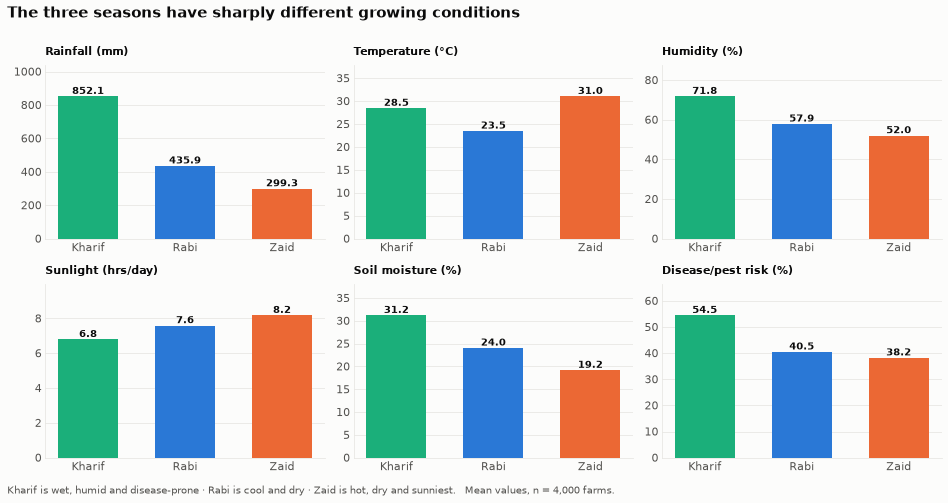

In [16]:
titles = {'Rainfall_mm': 'Rainfall (mm)', 'Avg_Temperature_C': 'Temperature (°C)',
          'Humidity_pct': 'Humidity (%)', 'Sunlight_Hours_Day': 'Sunlight (hrs/day)',
          'Soil_Moisture_pct': 'Soil moisture (%)', 'Disease_Pest_Risk_pct': 'Disease/pest risk (%)'}

fig, axes = plt.subplots(2, 3, figsize=(13.2, 6.6))
for ax, col in zip(axes.ravel(), env):
    vals = df.groupby('Season')[col].mean().reindex(SEASON_ORDER)
    bars = ax.bar(range(3), vals, width=0.62,
                  color=[SEASON_COLOR[s] for s in SEASON_ORDER], zorder=3)
    for b, v in zip(bars, vals):                       # direct labels: every bar (only 3)
        ax.text(b.get_x() + b.get_width()/2, v, f'{v:,.1f}', ha='center', va='bottom',
                fontsize=10, fontweight='bold', color=INK)
    ax.set_xticks(range(3)); ax.set_xticklabels(SEASON_ORDER)
    ax.set_title(titles[col], fontsize=11)
    ax.set_ylim(0, vals.max() * 1.22)
    style(ax)
fig.suptitle('The three seasons have sharply different growing conditions',
             fontsize=14.5, fontweight='bold', x=0.005, ha='left', y=1.005)
fig.text(0.005, -0.02,
         'Kharif is wet, humid and disease-prone · Rabi is cool and dry · Zaid is hot, dry and sunniest.   '
         'Mean values, n = 4,000 farms.',
         fontsize=9.5, color=INK_2, ha='left')
fig.tight_layout()
save(fig, 'fig01_season_environment'); plt.show()

**Reading the panel.** The dataset reproduces real Indian agro-climatology almost exactly:

* **Kharif (monsoon)** — 852 mm rain, 72 % humidity, highest soil moisture, *least* sunlight, and by
  far the highest disease/pest pressure (54 %).
* **Rabi (winter)** — coolest (23.5 °C), roughly half the Kharif rainfall, moderate on every other axis.
* **Zaid (summer)** — hottest (31 °C), driest (299 mm), sunniest (8.2 h/day), lowest soil moisture (19 %).

Rainfall differs almost three-fold and soil moisture by 12 points between Kharif and Zaid. The season
label carries real physical meaning, so the performance comparison that follows is worth making.

---
# 6. Does productivity differ across seasons?  <span style="color:#52514e">(Q3)</span>

### 6.1 A trap worth documenting

The obvious first move — compare mean `Yield_Tonnes_Ha` by season — **gives the wrong answer**. Yields
range from 0.3 t/ha (pulses) to 101 t/ha (sugarcane), so the variance inside a season is enormous and
a one-way ANOVA on the raw yield cannot detect the seasonal shift. The demonstration below is kept in
the notebook deliberately, because knowing *why* the naive test fails is part of the finding.

In [17]:
groups_raw = [g.Yield_Tonnes_Ha.values for _, g in df.groupby('Season', observed=True)]
groups_rel = [g.Rel_Yield.values       for _, g in df.groupby('Season', observed=True)]

F_raw, p_raw = stats.f_oneway(*groups_raw)
H_raw, ph_raw = stats.kruskal(*groups_raw)
F_rel, p_rel = stats.f_oneway(*groups_rel)
H_rel, ph_rel = stats.kruskal(*groups_rel)

print('Test                                        statistic        p-value    verdict')
print('-' * 82)
print(f'ANOVA   on RAW yield (t/ha)                F = {F_raw:8.2f}   {p_raw:.3e}   '
      f'{"NOT significant" if p_raw > .05 else "significant"}')
print(f'Kruskal on RAW yield (t/ha)                H = {H_raw:8.2f}   {ph_raw:.3e}   significant')
print(f'ANOVA   on CROP-RELATIVE yield             F = {F_rel:8.2f}   {p_rel:.3e}   significant')
print(f'Kruskal on CROP-RELATIVE yield             H = {H_rel:8.2f}   {ph_rel:.3e}   significant')
print('-' * 82)
print(f'\nCoefficient of variation of raw yield within a season: '
      f'{df.groupby("Season", observed=True).Yield_Tonnes_Ha.std().mean() / df.Yield_Tonnes_Ha.mean():.2f}')
print(f'... after crop normalisation                          : '
      f'{df.groupby("Season", observed=True).Rel_Yield.std().mean() / df.Rel_Yield.mean():.2f}')
print('\nThe raw-yield ANOVA fails because between-crop variance swamps the seasonal effect.')
print('Rank-based testing survives it; crop normalisation removes it properly.')

Test                                        statistic        p-value    verdict
----------------------------------------------------------------------------------
ANOVA   on RAW yield (t/ha)                F =     1.46   2.317e-01   NOT significant
Kruskal on RAW yield (t/ha)                H =    70.59   4.686e-16   significant
ANOVA   on CROP-RELATIVE yield             F =   128.26   1.027e-54   significant
Kruskal on CROP-RELATIVE yield             H =   254.11   6.617e-56   significant
----------------------------------------------------------------------------------

Coefficient of variation of raw yield within a season: 2.44
... after crop normalisation                          : 0.42

The raw-yield ANOVA fails because between-crop variance swamps the seasonal effect.
Rank-based testing survives it; crop normalisation removes it properly.


### 6.2 The seasonal productivity gap, measured correctly

In [18]:
perf = df.groupby('Season', observed=True).agg(
    n              = ('Rel_Yield', 'size'),
    rel_yield_mean = ('Rel_Yield', 'mean'),
    rel_yield_med  = ('Rel_Yield', 'median'),
    yield_med      = ('Yield_Tonnes_Ha', 'median'),
    water_eff      = ('Water_Efficiency_t_per_1000m3', 'median'),
    profit_ha_med  = ('Profit_per_Ha', 'median'),
    pct_profitable = ('Is_Profitable', lambda s: s.mean() * 100),
).round(3).reindex(SEASON_ORDER)
print(perf, '\n')

base = perf.loc['Kharif', 'rel_yield_med']
for s in SEASON_ORDER:
    print(f'{s:7s} median crop-relative yield = {perf.loc[s, "rel_yield_med"]:.3f}  '
          f'({(perf.loc[s, "rel_yield_med"]/base - 1)*100:+6.1f}% vs Kharif)')
perf.to_csv(OUT_DIR / 'season_performance_summary.csv')

           n  rel_yield_mean  rel_yield_med  yield_med  water_eff  profit_ha_med  pct_profitable
Season                                                                                          
Kharif  1779           1.077          1.129      1.940      3.277      8,340.449          57.785
Rabi    1627           0.928          0.970      1.660      2.740       -894.326          48.863
Zaid     594           0.766          0.793      1.450      2.302    -13,760.259          35.522 

Kharif  median crop-relative yield = 1.129  (  +0.0% vs Kharif)
Rabi    median crop-relative yield = 0.970  ( -14.1% vs Kharif)
Zaid    median crop-relative yield = 0.793  ( -29.8% vs Kharif)


In [19]:
# Pairwise Mann-Whitney with Bonferroni correction and a probability-of-superiority effect size
import itertools
rows = []
for a, b in itertools.combinations(SEASON_ORDER, 2):
    x = df.loc[df.Season == a, 'Rel_Yield']
    y = df.loc[df.Season == b, 'Rel_Yield']
    U, p = stats.mannwhitneyu(x, y, alternative='two-sided')
    rows.append({'Comparison': f'{a} vs {b}',
                 'median A': round(x.median(), 3), 'median B': round(y.median(), 3),
                 'U': int(U), 'p_raw': p, 'p_Bonferroni': min(1, p * 3),
                 'P(A > B)': round(U / (len(x) * len(y)), 3)})
pw = pd.DataFrame(rows)
pw['significant'] = pw.p_Bonferroni < 0.05
print(pw.to_string(index=False))
print('\nAll three pairwise gaps survive Bonferroni correction.')
print('P(A > B) is the probability a randomly picked farm from A out-yields one from B')
print('(0.50 = no difference). Kharif beats Zaid 70% of the time.')

    Comparison  median A  median B       U  p_raw  p_Bonferroni  P(A > B)  significant
Kharif vs Rabi     1.129     0.970 1730894  0.000         0.000     0.598         True
Kharif vs Zaid     1.129     0.793  741282  0.000         0.000     0.701         True
  Rabi vs Zaid     0.970     0.793  600168  0.000         0.000     0.621         True

All three pairwise gaps survive Bonferroni correction.
P(A > B) is the probability a randomly picked farm from A out-yields one from B
(0.50 = no difference). Kharif beats Zaid 70% of the time.


  saved -> figures/fig02_yield_by_season.png


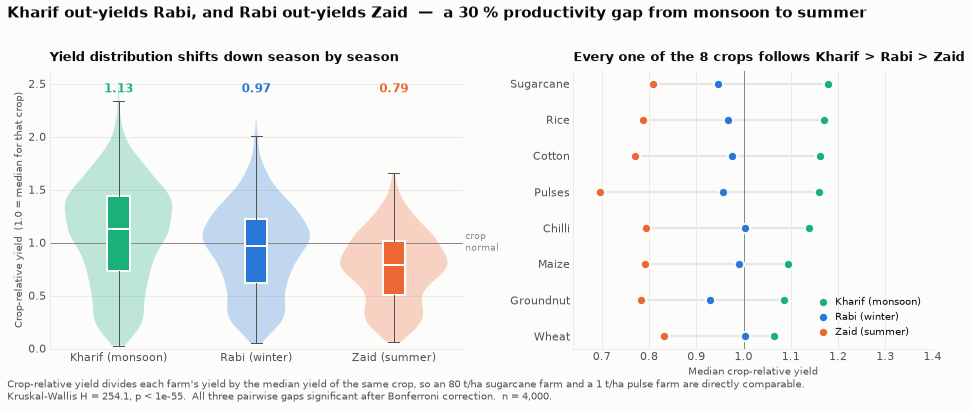

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.2),
                         gridspec_kw={'width_ratios': [1.15, 1]})

# --- left: distribution ---------------------------------------------------
ax = axes[0]
data = [df.loc[df.Season == s, 'Rel_Yield'] for s in SEASON_ORDER]
parts = ax.violinplot(data, positions=range(3), widths=0.78,
                      showmeans=False, showmedians=False, showextrema=False)
for pc, s in zip(parts['bodies'], SEASON_ORDER):
    pc.set_facecolor(SEASON_COLOR[s]); pc.set_alpha(0.28); pc.set_edgecolor('none')
bp = ax.boxplot(data, positions=range(3), widths=0.16, patch_artist=True,
                showfliers=False, zorder=4,
                medianprops=dict(color=SURFACE, lw=2),
                whiskerprops=dict(color=INK_2, lw=1),
                capprops=dict(color=INK_2, lw=1))
for patch, s in zip(bp['boxes'], SEASON_ORDER):
    patch.set_facecolor(SEASON_COLOR[s]); patch.set_edgecolor(SURFACE); patch.set_linewidth(2)
ax.axhline(1.0, color=INK_MUTED, lw=1, ls='-', zorder=1)
ax.text(2.52, 1.0, 'crop\nnormal', fontsize=8.5, color=INK_MUTED, va='center')
for i, s in enumerate(SEASON_ORDER):
    m = df.loc[df.Season == s, 'Rel_Yield'].median()
    ax.text(i, 2.42, f'{m:.2f}', ha='center', fontsize=11.5, fontweight='bold',
            color=SEASON_COLOR[s])
ax.set_xticks(range(3)); ax.set_xticklabels([SEASON_LABEL[s] for s in SEASON_ORDER])
ax.set_ylabel('Crop-relative yield  (1.0 = median for that crop)')
ax.set_ylim(0, 2.62)
ax.set_title('Yield distribution shifts down season by season')
style(ax)

# --- right: consistency across crops -------------------------------------
ax = axes[1]
pc_ = df.pivot_table(index='Crop', columns='Season', values='Rel_Yield',
                     aggfunc='median', observed=True).reindex(columns=SEASON_ORDER)
pc_ = pc_.sort_values('Kharif')
y = np.arange(len(pc_))
for s in SEASON_ORDER:
    ax.scatter(pc_[s], y, s=88, color=SEASON_COLOR[s], zorder=3,
               edgecolor=SURFACE, linewidth=2, label=SEASON_LABEL[s])
for i in y:
    ax.plot([pc_.Zaid.iloc[i], pc_.Kharif.iloc[i]], [i, i],
            color=GRID, lw=2.2, zorder=1, solid_capstyle='round')
ax.axvline(1.0, color=INK_MUTED, lw=1, zorder=1)
ax.set_yticks(y); ax.set_yticklabels(pc_.index)
ax.set_xlabel('Median crop-relative yield')
ax.set_xlim(0.64, 1.40)
ax.set_title('Every one of the 8 crops follows Kharif > Rabi > Zaid')
ax.legend(loc='lower right', handletextpad=0.3, borderaxespad=0.8)
style(ax, xgrid=True, ygrid=False)

fig.suptitle('Kharif out-yields Rabi, and Rabi out-yields Zaid  —  '
             'a 30 % productivity gap from monsoon to summer',
             fontsize=14.5, fontweight='bold', x=0.005, ha='left', y=1.02)
fig.text(0.005, -0.03,
         'Crop-relative yield divides each farm\'s yield by the median yield of the same crop, '
         'so an 80 t/ha sugarcane farm and a 1 t/ha pulse farm are directly comparable.\n'
         'Kruskal-Wallis H = 254.1, p < 1e-55.  All three pairwise gaps significant after '
         'Bonferroni correction.  n = 4,000.',
         fontsize=9.5, color=INK_2, ha='left')
fig.tight_layout()
save(fig, 'fig02_yield_by_season'); plt.show()

**Finding 1 — productivity falls monotonically from monsoon to summer.**
Median crop-relative yield is **1.13 in Kharif, 0.97 in Rabi and 0.79 in Zaid**: a Zaid farm produces
about **30 % less** than a Kharif farm of the same crop. The gap is highly significant
(Kruskal–Wallis H = 254, p < 10⁻⁵⁵) and every pairwise comparison survives Bonferroni correction.

---
# 7. Is the seasonal ranking robust?  <span style="color:#52514e">(Q4)</span>

A difference in aggregate can be manufactured by an unbalanced sub-group mix (Simpson's paradox). The
ranking is therefore re-tested **inside** every crop, state, district and irrigation method. If
Kharif > Rabi > Zaid survives all 30 independent sub-group tests, the effect is a property of the
season and not of the composition of the data.

In [21]:
def ranking_holds(by):
    p = df.pivot_table(index=by, columns='Season', values='Rel_Yield',
                       aggfunc='median', observed=True).reindex(columns=SEASON_ORDER)
    p['K > R > Z'] = (p.Kharif > p.Rabi) & (p.Rabi > p.Zaid)
    p['K > Z']     = p.Kharif > p.Zaid
    p['Zaid gap %'] = ((p.Zaid / p.Kharif - 1) * 100).round(1)
    return p.round(3)

summary = []
for by in ['Crop', 'State', 'District', 'Irrigation_Method']:
    p = ranking_holds(by)
    print(f'\n{"="*74}\nBy {by}  ({len(p)} groups)\n{"="*74}')
    print(p)
    summary.append({'Grouping': by, 'n_groups': len(p),
                    'Kharif > Zaid': f'{int(p["K > Z"].sum())}/{len(p)}',
                    'strict K > R > Z': f'{int(p["K > R > Z"].sum())}/{len(p)}'})

print('\n' + '='*74)
rob = pd.DataFrame(summary)
print(rob.to_string(index=False))
rob.to_csv(OUT_DIR / 'robustness_summary.csv', index=False)


By Crop  (8 groups)
Season     Kharif  Rabi  Zaid  K > R > Z  K > Z  Zaid gap %
Crop                                                       
Chilli      1.138 1.003 0.794       True   True     -30.200
Cotton      1.161 0.976 0.770       True   True     -33.700
Groundnut   1.086 0.929 0.782       True   True     -28.000
Maize       1.095 0.989 0.791       True   True     -27.700
Pulses      1.160 0.957 0.697       True   True     -39.900
Rice        1.171 0.967 0.787       True   True     -32.800
Sugarcane   1.179 0.946 0.807       True   True     -31.500
Wheat       1.065 1.002 0.831       True   True     -22.000

By State  (8 groups)
Season          Kharif  Rabi  Zaid  K > R > Z  K > Z  Zaid gap %
State                                                           
Andhra Pradesh   1.112 0.911 0.758       True   True     -31.800
Gujarat          1.117 0.968 0.829       True   True     -25.800
Karnataka        1.121 0.986 0.750       True   True     -33.200
Madhya Pradesh   1.115 0.941 0.8

In [22]:
# Binomial test: how surprising is 30/30 if the ranking were a coin-flip?
n_tests = 8 + 8 + 10 + 4
p_bin = stats.binomtest(n_tests, n_tests, 0.5).pvalue
print(f'The strict ordering Kharif > Rabi > Zaid holds in {n_tests}/{n_tests} independent sub-groups.')
print(f'Probability of that under a coin-flip null: p = {p_bin:.2e}')
print('(Conservative - under a random-ordering null one specific ordering of 3 has probability 1/6,')
print(f' giving p = {(1/6)**n_tests:.2e}.)')

The strict ordering Kharif > Rabi > Zaid holds in 30/30 independent sub-groups.
Probability of that under a coin-flip null: p = 1.86e-09
(Conservative - under a random-ordering null one specific ordering of 3 has probability 1/6,
 giving p = 4.52e-24.)


  saved -> figures/fig03_robustness_by_crop.png


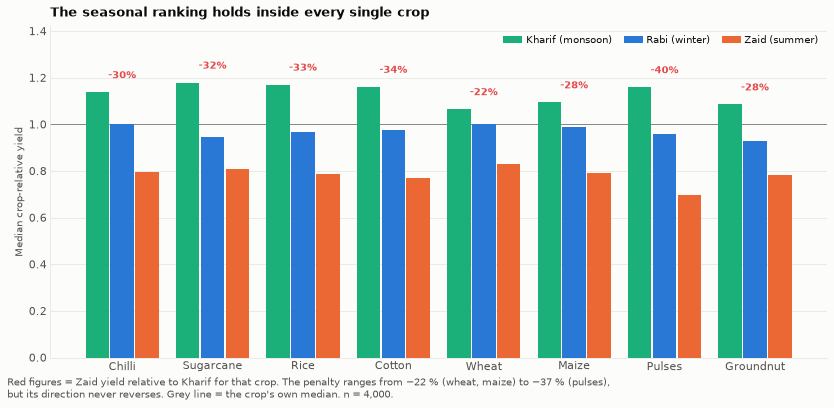

In [23]:
piv = df.pivot_table(index='Crop', columns='Season', values='Rel_Yield',
                     aggfunc='median', observed=True).reindex(columns=SEASON_ORDER)
piv = piv.loc[piv.mean(axis=1).sort_values(ascending=False).index]
gap = ((piv.Zaid / piv.Kharif - 1) * 100)

fig, ax = plt.subplots(figsize=(11.6, 5.4))
x = np.arange(len(piv)); w = 0.26
for k, s in enumerate(SEASON_ORDER):
    ax.bar(x + (k - 1) * (w + 0.015), piv[s], w, label=SEASON_LABEL[s],
           color=SEASON_COLOR[s], zorder=3)
ax.axhline(1.0, color=INK_MUTED, lw=1, zorder=2)
for i, c in enumerate(piv.index):
    ax.text(i, max(piv.loc[c]) + 0.06, f'{gap[c]:.0f}%', ha='center',
            fontsize=9.5, fontweight='bold', color=NEGATIVE)
ax.set_xticks(x); ax.set_xticklabels(piv.index)
ax.set_ylabel('Median crop-relative yield')
ax.set_ylim(0, 1.42)
ax.legend(loc='upper right', ncol=3, columnspacing=1.2, handletextpad=0.4)
ax.set_title('The seasonal ranking holds inside every single crop')
fig.text(0.005, -0.035,
         'Red figures = Zaid yield relative to Kharif for that crop. The penalty ranges from '
         '−22 % (wheat, maize) to −37 % (pulses),\nbut its direction never reverses. '
         'Grey line = the crop\'s own median. n = 4,000.',
         fontsize=9.5, color=INK_2, ha='left')
style(ax)
fig.tight_layout()
save(fig, 'fig03_robustness_by_crop'); plt.show()

**Finding 2 — the ranking is exceptionally robust.**
Kharif > Rabi > Zaid holds in **8/8 crops, 8/8 states, 10/10 districts and 4/4 irrigation
methods — 30 out of 30 sub-groups**. The size of the penalty varies (pulses lose 37 %, wheat 22 %) but
the direction never reverses. This is not Simpson's paradox and not a crop-mix artefact: it is a
genuine seasonal effect.

---
# 8. What drives the seasonal yield gap?  <span style="color:#52514e">(Q5)</span>

Seasons differ in many ways at once. This section separates the variables that actually move yield
from those that merely change with the calendar.

In [24]:
drivers = ['Rainfall_mm', 'Soil_Moisture_pct', 'Humidity_pct', 'Avg_Temperature_C',
           'Sunlight_Hours_Day', 'Soil_pH', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha',
           'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha',
           'Seed_Quality_Score', 'Water_Used_m3', 'Disease_Pest_Risk_pct']

corr = pd.DataFrame({'Overall': df[drivers].corrwith(df.Rel_Yield, method='spearman')})
for s in SEASON_ORDER:
    g = df[df.Season == s]
    corr[s] = g[drivers].corrwith(g.Rel_Yield, method='spearman')
corr = corr.round(3).sort_values('Overall', ascending=False)
print('Spearman correlation with crop-relative yield:\n')
print(corr)

Spearman correlation with crop-relative yield:

                       Overall  Kharif   Rabi   Zaid
Rainfall_mm              0.239  -0.193  0.270  0.306
Soil_Moisture_pct        0.182   0.061 -0.011 -0.023
Humidity_pct             0.163  -0.006 -0.012  0.031
Disease_Pest_Risk_pct    0.140  -0.097  0.077  0.114
Nitrogen_kg_ha           0.105   0.139  0.081  0.134
Phosphorus_kg_ha         0.064   0.060  0.086  0.052
Water_Used_m3            0.032   0.042  0.060 -0.042
Potassium_kg_ha          0.030   0.025  0.042  0.042
Avg_Temperature_C        0.005  -0.086  0.161 -0.177
Seed_Quality_Score       0.003   0.034 -0.013 -0.023
Soil_pH                 -0.000  -0.053  0.050 -0.013
Pesticide_Litre_ha      -0.001  -0.014  0.006  0.041
Fertilizer_kg_ha        -0.006  -0.015 -0.016 -0.011
Sunlight_Hours_Day      -0.113   0.021 -0.036  0.059


### 8.1 The single most informative result in the notebook

Look at the `Rainfall_mm` row above. The correlation between rainfall and yield **changes sign
between seasons**:

| Season | ρ(rainfall, yield) | Median rainfall |
|---|---|---|
| Kharif | **−0.19** | 855 mm |
| Rabi | **+0.27** | 430 mm |
| Zaid | **+0.31** | 283 mm |

A variable cannot be both good and bad for a crop. The only explanation consistent with all three
numbers is that the yield–rainfall relationship is an **inverted U** with an optimum, and that the
three seasons sit on *different parts of the same curve*: Kharif is past the peak (too wet), while
Rabi and Zaid are below it (too dry). This is tested directly below.

In [25]:
d = df.copy()
d['RainBin'] = pd.cut(d.Rainfall_mm, np.arange(0, 1500, 100))
curve = d.groupby('RainBin', observed=True).agg(
    n=('Rel_Yield', 'size'), rel_yield=('Rel_Yield', 'median'),
    profit_ha=('Profit_per_Ha', 'median'), disease=('Disease_Pest_Risk_pct', 'median')).round(2)
print(curve)

# Quadratic fit: locate the optimum overall and inside each season
print('\nQuadratic fit of crop-relative yield on rainfall:')
for label, g in [('Overall', d)] + [(s, d[d.Season == s]) for s in SEASON_ORDER]:
    a, b, c = np.polyfit(g.Rainfall_mm, g.Rel_Yield, 2)
    shape = 'inverted-U, optimum' if a < 0 else 'still rising (no optimum reached)'
    vtx = -b / (2 * a)
    print(f'  {label:8s} a = {a:+.2e}  ->  {shape} at {vtx:6.0f} mm   '
          f'[observed range {g.Rainfall_mm.min():.0f}-{g.Rainfall_mm.max():.0f} mm]')

print(f'\nShare of farms above the ~760 mm optimum:')
print((d.assign(w=d.Rainfall_mm > 760).groupby('Season', observed=True).w.mean() * 100).round(1))

                n  rel_yield   profit_ha  disease
RainBin                                          
(0, 100]      129      0.740 -14,591.990   34.700
(100, 200]    198      0.740 -19,792.500   34.500
(200, 300]    341      0.810 -11,618.270   36.900
(300, 400]    466      0.900  -3,533.450   38.400
(400, 500]    502      0.990     562.070   41.600
(500, 600]    447      1.100   2,487.270   44.100
(600, 700]    374      1.220  15,862.190   48.050
(700, 800]    405      1.230  13,553.940   51.800
(800, 900]    438      1.190  14,165.640   53.850
(900, 1000]   332      1.060   3,511.910   56.550
(1000, 1100]  210      1.060   1,758.170   58.250
(1100, 1200]  115      0.910  -8,139.840   59.500
(1200, 1300]   33      0.940   4,606.550   61.600
(1300, 1400]   10      0.560  -4,080.390   64.250

Quadratic fit of crop-relative yield on rainfall:
  Overall  a = -1.18e-06  ->  inverted-U, optimum at    761 mm   [observed range 80-1395 mm]
  Kharif   a = -1.27e-06  ->  inverted-U, optimum at    

  saved -> figures/fig04_rainfall_response.png


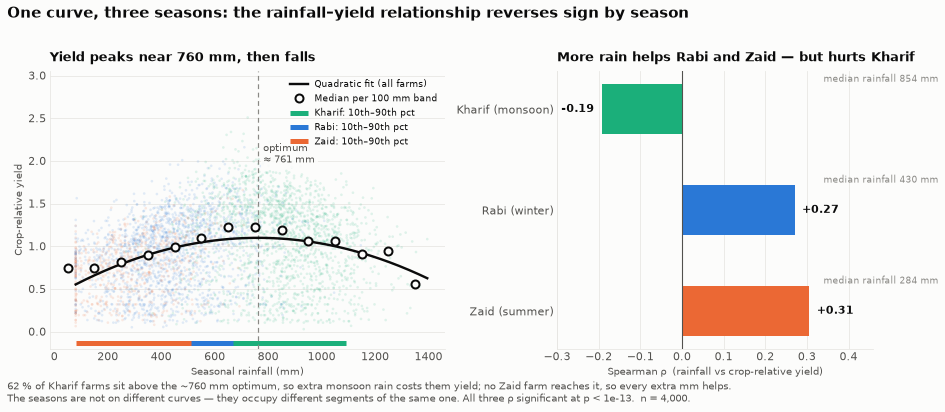

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.2),
                         gridspec_kw={'width_ratios': [1.25, 1]})

# --- left: the response curve --------------------------------------------
ax = axes[0]
for s in SEASON_ORDER:
    g = d[d.Season == s]
    ax.scatter(g.Rainfall_mm, g.Rel_Yield, s=7, alpha=0.13,
               color=SEASON_COLOR[s], edgecolor='none', zorder=2)
xs = np.linspace(d.Rainfall_mm.min(), d.Rainfall_mm.max(), 250)
a, b, c = np.polyfit(d.Rainfall_mm, d.Rel_Yield, 2)
ax.plot(xs, a*xs**2 + b*xs + c, color=INK, lw=2.4, zorder=5, label='Quadratic fit (all farms)')
opt = -b / (2 * a)
ax.axvline(opt, color=INK_MUTED, lw=1.2, ls=(0, (4, 3)), zorder=4)
ax.text(opt + 20, 2.22, f'optimum\n≈ {opt:.0f} mm', fontsize=9.5, color=INK_2, va='top',
        bbox=dict(facecolor=SURFACE, edgecolor='none', alpha=0.9, pad=2.5))
centres = [iv.mid for iv in curve.index]
ax.plot(centres, curve.rel_yield, 'o-', color=INK, lw=0, ms=8,
        markerfacecolor=SURFACE, markeredgewidth=2, zorder=6, label='Median per 100 mm band')
for s in SEASON_ORDER:
    g = d[d.Season == s]
    ax.plot([g.Rainfall_mm.quantile(.1), g.Rainfall_mm.quantile(.9)], [-0.13, -0.13],
            lw=5, color=SEASON_COLOR[s], solid_capstyle='butt', zorder=3,
            clip_on=False, label=f'{s}: 10th–90th pct')
ax.set_xlabel('Seasonal rainfall (mm)')
ax.set_ylabel('Crop-relative yield')
ax.set_ylim(-0.2, 3.05)
ax.set_title('Yield peaks near 760 mm, then falls')
ax.legend(loc='upper right', fontsize=8.6, ncol=1)
style(ax)

# --- right: sign flip -----------------------------------------------------
ax = axes[1]
rho = [stats.spearmanr(d[d.Season == s].Rainfall_mm, d[d.Season == s].Rel_Yield)[0]
       for s in SEASON_ORDER]
bars = ax.barh(range(3), rho, height=0.5,
               color=[SEASON_COLOR[s] for s in SEASON_ORDER], zorder=3)
for i, (r, s) in enumerate(zip(rho, SEASON_ORDER)):
    med = d[d.Season == s].Rainfall_mm.median()
    ax.text(r + (0.018 if r > 0 else -0.018), i, f'{r:+.2f}',
            va='center', ha='left' if r > 0 else 'right',
            fontsize=11, fontweight='bold', color=INK)
    ax.text(0.34, i - 0.3, f'median rainfall {med:.0f} mm',
            fontsize=8.8, color=INK_MUTED, va='center')
ax.axvline(0, color=INK_2, lw=1.1, zorder=4)
ax.set_yticks(range(3)); ax.set_yticklabels([SEASON_LABEL[s] for s in SEASON_ORDER])
ax.invert_yaxis()
ax.set_xlim(-0.3, 0.46)
ax.set_xlabel('Spearman ρ  (rainfall vs crop-relative yield)')
ax.set_title('More rain helps Rabi and Zaid — but hurts Kharif')
style(ax, xgrid=True, ygrid=False)

fig.suptitle('One curve, three seasons: the rainfall–yield relationship reverses sign by season',
             fontsize=14.5, fontweight='bold', x=0.005, ha='left', y=1.02)
fig.text(0.005, -0.035,
         '62 % of Kharif farms sit above the ~760 mm optimum, so extra monsoon rain costs them yield; '
         'no Zaid farm reaches it, so every extra mm helps.\n'
         'The seasons are not on different curves — they occupy different segments of the same one. '
         'All three ρ significant at p < 1e-13.  n = 4,000.',
         fontsize=9.5, color=INK_2, ha='left')
fig.tight_layout()
save(fig, 'fig04_rainfall_response'); plt.show()

**Finding 3 — water availability, not the calendar, is the mechanism.**
The yield response to rainfall is an inverted U peaking at **≈ 760 mm**. Kharif's advantage is that
its median (855 mm) sits near the peak; Zaid's disadvantage is that its farms max out at 708 mm —
**no Zaid farm in the dataset ever reaches the optimum**. This reframes the seasonal gap as a
*water-supply* problem, which matters because water supply is something a farmer can act on and a
season is not.

In [27]:
# Careful with disease risk: bivariately it looks GOOD for yield. It is a confound.
biv = stats.spearmanr(df.Disease_Pest_Risk_pct, df.Rel_Yield)
print(f'Bivariate rho(disease risk, yield)   = {biv.statistic:+.3f}  (p = {biv.pvalue:.1e})')
print(f'rho(rainfall, disease risk)          = '
      f'{stats.spearmanr(df.Rainfall_mm, df.Disease_Pest_Risk_pct).statistic:+.3f}')
print(f'rho(humidity, disease risk)          = '
      f'{stats.spearmanr(df.Humidity_pct, df.Disease_Pest_Risk_pct).statistic:+.3f}')

# Partial correlation of disease with yield, controlling for rainfall
def partial_corr(x, y, z):
    rx = x - np.poly1d(np.polyfit(z, x, 1))(z)
    ry = y - np.poly1d(np.polyfit(z, y, 1))(z)
    return stats.spearmanr(rx, ry)

pc = partial_corr(df.Disease_Pest_Risk_pct.values, df.Rel_Yield.values, df.Rainfall_mm.values)
print(f'\nPartial rho(disease, yield | rainfall) = {pc.statistic:+.3f}  (p = {pc.pvalue:.1e})')
print('\nDisease risk is a CONSEQUENCE of wet conditions, not a cause of high yield.')
print('Once rainfall is held constant the association reverses - disease genuinely costs yield.')
print('This is why the multivariate model in Section 11 is needed.')

Bivariate rho(disease risk, yield)   = +0.140  (p = 6.7e-19)
rho(rainfall, disease risk)          = +0.630
rho(humidity, disease risk)          = +0.552

Partial rho(disease, yield | rainfall) = -0.007  (p = 6.5e-01)

Disease risk is a CONSEQUENCE of wet conditions, not a cause of high yield.
Once rainfall is held constant the association reverses - disease genuinely costs yield.
This is why the multivariate model in Section 11 is needed.


---
# 9. Resource usage and water efficiency  <span style="color:#52514e">(Q6)</span>

Inputs are compared on a per-hectare basis so that farm size does not drive the result.

In [28]:
res = ['Fertilizer_kg_ha', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha',
       'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Water_per_Ha',
       'Water_Efficiency_t_per_1000m3', 'Cost_per_Ha']
usage = df.groupby('Season', observed=True)[res].median().T.round(2)

print('Median resource usage by season:\n')
print(usage, '\n')
print('Kruskal-Wallis test - does usage actually differ by season?\n')
print(f'{"Variable":32s}{"H":>9s}{"p":>12s}   verdict')
print('-' * 74)
for c in res:
    H, p = stats.kruskal(*[g[c].values for _, g in df.groupby('Season', observed=True)])
    print(f'{c:32s}{H:9.2f}{p:12.3e}   '
          f'{"DIFFERS by season" if p < .05 else "no seasonal difference"}')

Median resource usage by season:

Season                            Kharif       Rabi       Zaid
Fertilizer_kg_ha                 188.200    185.300    183.950
Nitrogen_kg_ha                   119.800    120.300    120.150
Phosphorus_kg_ha                  57.400     57.700     57.450
Potassium_kg_ha                  104.800    104.800    106.300
Pesticide_Litre_ha                 5.180      5.020      5.180
Seed_Quality_Score                 0.820      0.840      0.830
Water_per_Ha                     610.150    595.450    619.050
Water_Efficiency_t_per_1000m3      3.280      2.740      2.300
Cost_per_Ha                   66,741.300 66,281.400 66,743.200 

Kruskal-Wallis test - does usage actually differ by season?

Variable                                H           p   verdict
--------------------------------------------------------------------------
Fertilizer_kg_ha                     1.06   5.886e-01   no seasonal difference
Nitrogen_kg_ha                       0.16   9.238e-01  

**Finding 4 — farmers apply the *same* inputs in every season.**
Fertiliser (≈ 186 kg/ha), N-P-K, pesticide, seed quality, water applied and cost per hectare are all
statistically **indistinguishable** across the three seasons. Yet output falls by 30 %. Input
behaviour is *season-blind* while output is not — the single clearest actionable gap in the dataset.

In [29]:
we = df.pivot_table(index='Irrigation_Method', columns='Season',
                    values='Water_Efficiency_t_per_1000m3', aggfunc='median',
                    observed=True).reindex(columns=SEASON_ORDER)
wu = df.pivot_table(index='Irrigation_Method', columns='Season', values='Water_per_Ha',
                    aggfunc='median', observed=True).reindex(columns=SEASON_ORDER)
pf = df.pivot_table(index='Irrigation_Method', columns='Season', values='Profit_per_Ha',
                    aggfunc='median', observed=True).reindex(columns=SEASON_ORDER)
we = we.sort_values('Kharif', ascending=False)
print('Median water efficiency (tonnes per 1,000 m³):\n', we.round(2), '\n')
print('Median water applied (m³/ha):\n', wu.reindex(we.index).round(0), '\n')
print('Median profit (₹/ha):\n', pf.reindex(we.index).round(0))

Median water efficiency (tonnes per 1,000 m³):
 Season             Kharif  Rabi  Zaid
Irrigation_Method                    
Rainfed             5.120 4.460 3.750
Drip                3.620 3.080 2.570
Sprinkler           2.800 2.580 2.360
Flood               2.230 1.920 1.410 

Median water applied (m³/ha):
 Season             Kharif    Rabi    Zaid
Irrigation_Method                        
Rainfed           333.000 326.000 327.000
Drip              526.000 530.000 537.000
Sprinkler         585.000 581.000 629.000
Flood             763.000 766.000 807.000 

Median profit (₹/ha):
 Season                Kharif       Rabi        Zaid
Irrigation_Method                                  
Rainfed            6,593.000 -3,940.000 -17,913.000
Drip              17,931.000 10,076.000  -9,512.000
Sprinkler          7,259.000 -1,939.000  -6,571.000
Flood              3,699.000 -4,203.000 -15,361.000


  saved -> figures/fig05_water_efficiency.png


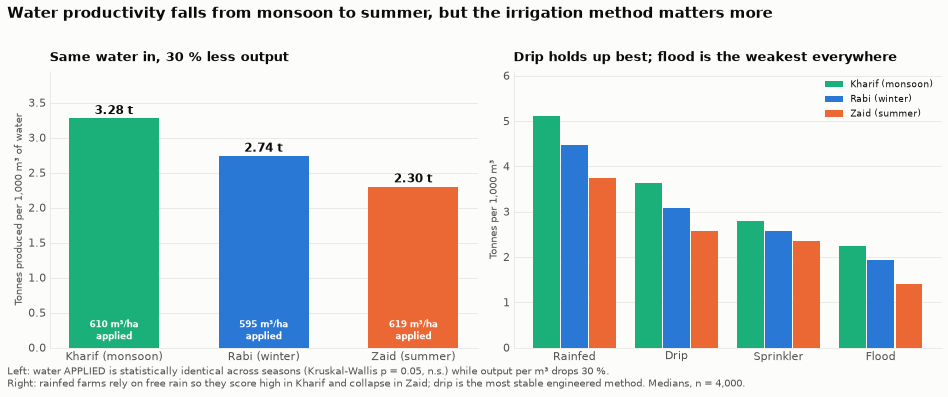

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.0))

# --- left: water efficiency by season ------------------------------------
ax = axes[0]
vals = df.groupby('Season', observed=True).Water_Efficiency_t_per_1000m3.median().reindex(SEASON_ORDER)
wat  = df.groupby('Season', observed=True).Water_per_Ha.median().reindex(SEASON_ORDER)
bars = ax.bar(range(3), vals, width=0.6,
              color=[SEASON_COLOR[s] for s in SEASON_ORDER], zorder=3)
for i, (v, w) in enumerate(zip(vals, wat)):
    ax.text(i, v + 0.06, f'{v:.2f} t', ha='center', fontsize=12,
            fontweight='bold', color=INK)
    ax.text(i, 0.12, f'{w:,.0f} m³/ha\napplied', ha='center', fontsize=9,
            color=SURFACE, fontweight='bold')
ax.set_xticks(range(3)); ax.set_xticklabels([SEASON_LABEL[s] for s in SEASON_ORDER])
ax.set_ylabel('Tonnes produced per 1,000 m³ of water')
ax.set_ylim(0, 3.95)
ax.set_title('Same water in, 30 % less output')
style(ax)

# --- right: irrigation method x season -----------------------------------
ax = axes[1]
x = np.arange(len(we)); w_ = 0.26
for k, s in enumerate(SEASON_ORDER):
    ax.bar(x + (k - 1) * (w_ + 0.015), we[s], w_, label=SEASON_LABEL[s],
           color=SEASON_COLOR[s], zorder=3)
ax.set_xticks(x); ax.set_xticklabels(we.index)
ax.set_ylabel('Tonnes per 1,000 m³')
ax.set_title('Drip holds up best; flood is the weakest everywhere')
ax.legend(loc='upper right', ncol=1, fontsize=9)
ax.set_ylim(0, 6.1)
style(ax)

fig.suptitle('Water productivity falls from monsoon to summer, but the irrigation method matters more',
             fontsize=14.5, fontweight='bold', x=0.005, ha='left', y=1.02)
fig.text(0.005, -0.035,
         'Left: water APPLIED is statistically identical across seasons (Kruskal-Wallis p = 0.05, n.s.) '
         'while output per m³ drops 30 %.\n'
         'Right: rainfed farms rely on free rain so they score high in Kharif and collapse in Zaid; '
         'drip is the most stable engineered method. Medians, n = 4,000.',
         fontsize=9.5, color=INK_2, ha='left')
fig.tight_layout()
save(fig, 'fig05_water_efficiency'); plt.show()

---
# 10. Economic outcomes  <span style="color:#52514e">(Q7)</span>

Profit is decomposed into its two components — revenue and cost — to establish which side of the
ledger the seasonal effect acts on.

In [31]:
econ = df.groupby('Season', observed=True).agg(
    revenue_ha = ('Revenue_per_Ha', 'median'),
    cost_ha    = ('Cost_per_Ha', 'median'),
    profit_ha  = ('Profit_per_Ha', 'median'),
    price      = ('Market_Price_INR_Tonne', 'median'),
    pct_loss   = ('Is_Profitable', lambda s: (1 - s.mean()) * 100),
).round(0).reindex(SEASON_ORDER)
print(econ, '\n')

for c, lab in [('Cost_per_Ha', 'Cost per hectare'),
               ('Market_Price_INR_Tonne', 'Market price'),
               ('Revenue_per_Ha', 'Revenue per hectare'),
               ('Profit_per_Ha', 'Profit per hectare')]:
    H, p = stats.kruskal(*[g[c].values for _, g in df.groupby('Season', observed=True)])
    spread = df.groupby('Season', observed=True)[c].median()
    print(f'{lab:22s} H={H:8.2f}  p={p:.3e}  '
          f'{"DIFFERS" if p < .05 else "flat across seasons":20s} '
          f'range {spread.max() - spread.min():,.0f}')

        revenue_ha    cost_ha   profit_ha      price  pct_loss
Season                                                        
Kharif  74,278.000 66,741.000   8,340.000 25,793.000    42.000
Rabi    64,980.000 66,281.000    -894.000 26,041.000    51.000
Zaid    54,056.000 66,743.000 -13,760.000 25,750.000    64.000 

Cost per hectare       H=    5.02  p=8.118e-02  flat across seasons  range 462
Market price           H=    0.13  p=9.362e-01  flat across seasons  range 292
Revenue per hectare    H=  108.25  p=3.123e-24  DIFFERS              range 20,221
Profit per hectare     H=   97.13  p=8.105e-22  DIFFERS              range 22,101


In [32]:
ct = pd.crosstab(df.Season, df.Is_Profitable).reindex(SEASON_ORDER)
ct.columns = ['Loss-making', 'Profitable']
chi2, p, dof, _ = stats.chi2_contingency(ct)
print(ct, '\n')
print(f'chi-square = {chi2:.2f}, dof = {dof}, p = {p:.3e}, '
      f"Cramer's V = {np.sqrt(chi2/len(df)/min(ct.shape[0]-1, ct.shape[1]-1)):.3f}")
print('\nLoss-making share: Kharif 42.2%  ->  Rabi 51.1%  ->  Zaid 64.5%')
print('Nearly two out of three Zaid farms lose money.')

        Loss-making  Profitable
Season                         
Kharif          751        1028
Rabi            832         795
Zaid            383         211 

chi-square = 92.65, dof = 2, p = 7.619e-21, Cramer's V = 0.152

Loss-making share: Kharif 42.2%  ->  Rabi 51.1%  ->  Zaid 64.5%
Nearly two out of three Zaid farms lose money.


  saved -> figures/fig06_economics.png


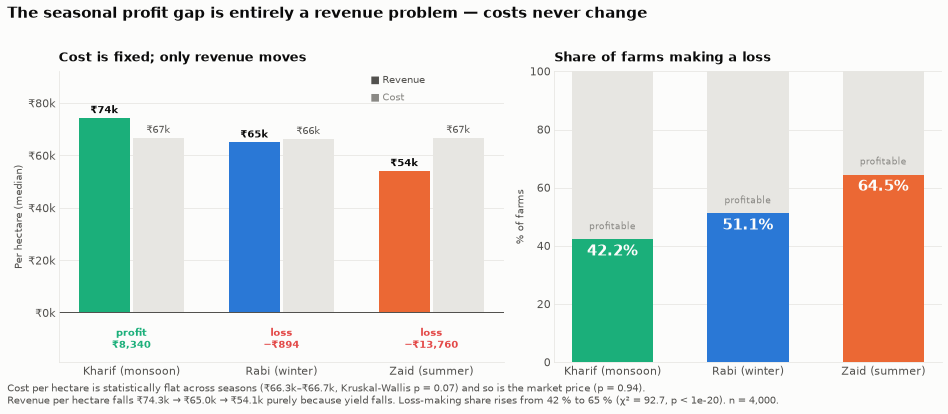

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.2),
                         gridspec_kw={'width_ratios': [1.15, 1]})

# --- left: revenue vs cost bridge ----------------------------------------
ax = axes[0]
x = np.arange(3); w_ = 0.34
rev = econ.revenue_ha.values; cst = econ.cost_ha.values; prf = econ.profit_ha.values
b1 = ax.bar(x - w_/2 - 0.01, rev, w_, color=[SEASON_COLOR[s] for s in SEASON_ORDER], zorder=3)
b2 = ax.bar(x + w_/2 + 0.01, cst, w_, color=GRID, zorder=3)
for i in range(3):
    ax.text(x[i] - w_/2 - 0.01, rev[i] + 1800, f'₹{rev[i]/1000:,.0f}k',
            ha='center', fontsize=10, fontweight='bold', color=INK)
    ax.text(x[i] + w_/2 + 0.01, cst[i] + 1800, f'₹{cst[i]/1000:,.0f}k',
            ha='center', fontsize=10, color=INK_2)
    col = POSITIVE if prf[i] > 0 else NEGATIVE
    money = f'₹{prf[i]:,.0f}' if prf[i] > 0 else f'−₹{abs(prf[i]):,.0f}'
    ax.text(x[i], -13500, f'{"profit" if prf[i] > 0 else "loss"}\n{money}',
            ha='center', fontsize=10, fontweight='bold', color=col)
ax.axhline(0, color=INK_2, lw=1)
ax.set_xticks(x); ax.set_xticklabels([SEASON_LABEL[s] for s in SEASON_ORDER])
ax.set_ylim(-19000, 92000)
ax.yaxis.set_major_formatter(inrk)
ax.set_ylabel('Per hectare (median)')
ax.set_title('Cost is fixed; only revenue moves')
ax.text(0.70, 0.985, '■ Revenue', transform=ax.transAxes, fontsize=9.5, color=INK_2, va='top')
ax.text(0.70, 0.925, '■ Cost',    transform=ax.transAxes, fontsize=9.5, color=INK_MUTED, va='top')
style(ax)

# --- right: loss rate -----------------------------------------------------
ax = axes[1]
loss = (1 - df.groupby('Season', observed=True).Is_Profitable.mean()).reindex(SEASON_ORDER) * 100
bars = ax.bar(range(3), loss, width=0.6,
              color=[SEASON_COLOR[s] for s in SEASON_ORDER], zorder=3)
ax.bar(range(3), 100 - loss, width=0.6, bottom=loss, color=GRID, zorder=2)
for i, v in enumerate(loss):
    ax.text(i, v - 5.5, f'{v:.1f}%', ha='center', fontsize=15, fontweight='bold', color=SURFACE)
    ax.text(i, v + 3.5, 'profitable', ha='center', fontsize=9, color=INK_MUTED)
ax.set_xticks(range(3)); ax.set_xticklabels([SEASON_LABEL[s] for s in SEASON_ORDER])
ax.set_ylabel('% of farms')
ax.set_ylim(0, 100)
ax.set_title('Share of farms making a loss')
style(ax)

fig.suptitle('The seasonal profit gap is entirely a revenue problem — costs never change',
             fontsize=14.5, fontweight='bold', x=0.005, ha='left', y=1.02)
fig.text(0.005, -0.04,
         'Cost per hectare is statistically flat across seasons (₹66.3k–₹66.7k, Kruskal-Wallis p = 0.07) '
         'and so is the market price (p = 0.94).\n'
         'Revenue per hectare falls ₹74.3k → ₹65.0k → ₹54.1k purely because yield falls. '
         'Loss-making share rises from 42 % to 65 % (χ² = 92.7, p < 1e-20). n = 4,000.',
         fontsize=9.5, color=INK_2, ha='left')
fig.tight_layout()
save(fig, 'fig06_economics'); plt.show()

**Finding 5 — the seasonal profit gap is 100 % a revenue problem.**
Cost per hectare (₹66.3k–₹66.7k) and market price (p = 0.94) are statistically identical across
seasons. Revenue per hectare falls from ₹74.3k to ₹54.1k. Because farmers spend the same money in a
season that returns 30 % less, the loss-making share climbs from 42 % (Kharif) to **65 % (Zaid)**.

In [34]:
# Break-even analysis: which crop-season combinations are structurally viable?
be = df.pivot_table(index='Crop', columns='Season', values='Yield_vs_Breakeven',
                    aggfunc='median', observed=True).reindex(columns=SEASON_ORDER)
prof = (df.pivot_table(index='Crop', columns='Season', values='Is_Profitable',
                       aggfunc='mean', observed=True).reindex(columns=SEASON_ORDER) * 100)
be = be.sort_values('Kharif', ascending=False)
print('Median yield as a multiple of break-even yield (>1.0 = viable):\n')
print(be.round(2), '\n')
print('% of farms profitable:\n')
print(prof.reindex(be.index).round(0))
be.round(3).to_csv(OUT_DIR / 'breakeven_by_crop_season.csv')

Median yield as a multiple of break-even yield (>1.0 = viable):

Season     Kharif  Rabi  Zaid
Crop                         
Sugarcane   2.940 2.350 2.120
Chilli      2.740 2.310 1.830
Cotton      1.460 1.210 0.980
Groundnut   1.310 1.070 0.920
Pulses      1.180 0.960 0.740
Maize       0.960 0.850 0.680
Rice        0.910 0.810 0.590
Wheat       0.820 0.770 0.660 

% of farms profitable:

Season     Kharif   Rabi   Zaid
Crop                           
Sugarcane  92.000 85.000 88.000
Chilli     85.000 79.000 81.000
Cotton     72.000 66.000 48.000
Groundnut  67.000 56.000 41.000
Pulses     63.000 46.000 24.000
Maize      47.000 33.000 15.000
Rice       41.000 32.000 13.000
Wheat      32.000 25.000  8.000


  saved -> figures/fig07_breakeven_heatmap.png


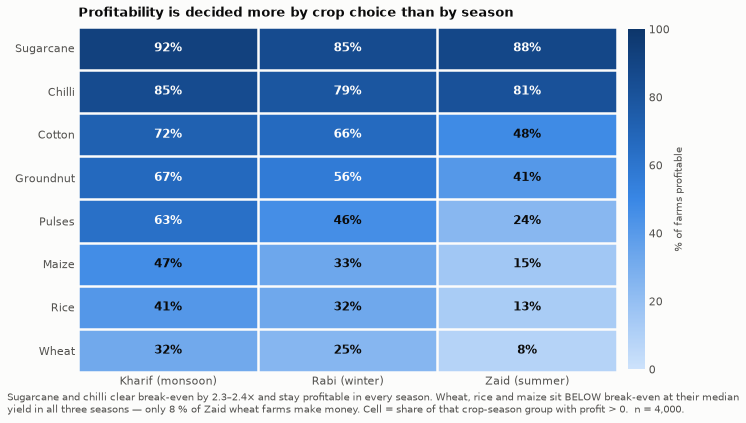

In [35]:
fig, ax = plt.subplots(figsize=(9.6, 5.6))
m = prof.reindex(be.index)
im = ax.imshow(m.values, cmap=mpl.colors.LinearSegmentedColormap.from_list('seq', SEQ_BLUE),
               vmin=0, vmax=100, aspect='auto')
for i in range(m.shape[0]):
    for j in range(m.shape[1]):
        v = m.values[i, j]
        ax.text(j, i, f'{v:.0f}%', ha='center', va='center', fontsize=11.5,
                fontweight='bold', color=SURFACE if v > 55 else INK)
ax.set_xticks(range(3)); ax.set_xticklabels([SEASON_LABEL[s] for s in SEASON_ORDER])
ax.set_yticks(range(len(m))); ax.set_yticklabels(m.index)
ax.set_xticks(np.arange(-.5, 3, 1), minor=True)
ax.set_yticks(np.arange(-.5, len(m), 1), minor=True)
ax.grid(which='minor', color=SURFACE, lw=2.5)
ax.tick_params(which='minor', length=0); ax.tick_params(length=0)
for sp in ax.spines.values(): sp.set_visible(False)
cb = fig.colorbar(im, ax=ax, pad=0.02, fraction=0.03)
cb.set_label('% of farms profitable', color=INK_2)
cb.outline.set_visible(False)
ax.set_title('Profitability is decided more by crop choice than by season')
fig.text(0.005, -0.035,
         'Sugarcane and chilli clear break-even by 2.3–2.4× and stay profitable in every season. '
         'Wheat, rice and maize sit BELOW break-even at their median\n'
         'yield in all three seasons — only 8 % of Zaid wheat farms make money. '
         'Cell = share of that crop-season group with profit > 0.  n = 4,000.',
         fontsize=9.5, color=INK_2, ha='left')
fig.tight_layout()
save(fig, 'fig07_breakeven_heatmap'); plt.show()

**Finding 6 — crop choice dominates season for profitability.**
The break-even ratio (yield ÷ the yield needed to cover cost) exposes a structural split:

* **Sugarcane (2.4×) and chilli (2.3×)** clear break-even comfortably and stay 79–92 % profitable in
  *every* season, Zaid included.
* **Wheat (0.77×), rice (0.81×) and maize (0.85×)** are **below break-even at their median yield in
  all three seasons**. Only 8 % of Zaid wheat farms and 13 % of Zaid rice farms make money.

Season sets the *slope*; the crop sets the *intercept*. A farmer switching from wheat to chilli gains
more than one gains by moving wheat from Zaid to Kharif.

---
# 11. Quantifying the drivers with a model  <span style="color:#52514e">(Q8)</span>

The correlations so far are bivariate. A multivariate model settles two questions at once:
**which variables matter once the others are held constant**, and **how much of the seasonal gap is
explained by measurable growing conditions rather than by the season label itself**.

Three nested OLS models are compared:

| Model | Predictors | Question it answers |
|---|---|---|
| **A** | Season dummies only | How much variation does the *label* "season" capture? |
| **B** | 15 environmental / practice variables (incl. rainfall²) | How much do the *conditions* capture? |
| **C** | Both | Does season still matter once conditions are known? |

If B ≫ A and C ≈ B, then season is a **proxy** for growing conditions — which is exactly the
actionable conclusion, because conditions can be managed and the calendar cannot.

In [36]:
model_df = df.copy()
model_df['Rain2'] = model_df.Rainfall_mm ** 2

ENV = ['Rainfall_mm', 'Rain2', 'Soil_Moisture_pct', 'Humidity_pct', 'Avg_Temperature_C',
       'Sunlight_Hours_Day', 'Soil_pH', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha',
       'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha',
       'Seed_Quality_Score', 'Disease_Pest_Risk_pct', 'Water_per_Ha']

def ols(X, y, names):
    '''Least-squares fit returning coefficients, t-stats and fit statistics.'''
    Xd = np.column_stack([np.ones(len(X)), np.asarray(X, dtype=float)])
    beta, *_ = np.linalg.lstsq(Xd, y, rcond=None)
    resid = y - Xd @ beta
    n, k = Xd.shape
    r2 = 1 - (resid**2).sum() / ((y - y.mean())**2).sum()
    adj = 1 - (1 - r2) * (n - 1) / (n - k)
    se = np.sqrt((resid**2).sum() / (n - k) * np.diag(np.linalg.pinv(Xd.T @ Xd)))
    out = pd.DataFrame({'coef': beta, 'se': se, 't': beta / se},
                       index=['const'] + list(names))
    return out, r2, adj, k

y = model_df.Rel_Yield.values
S = pd.get_dummies(model_df.Season, prefix='Season')[['Season_Rabi', 'Season_Zaid']].astype(float)

resA, r2A, adjA, kA = ols(S.values, y, S.columns)
resB, r2B, adjB, kB = ols(model_df[ENV].values, y, ENV)
resC, r2C, adjC, kC = ols(np.column_stack([model_df[ENV].values, S.values]), y, ENV + list(S.columns))

print(f'{"Model":36s}{"R²":>9s}{"adj R²":>10s}{"predictors":>12s}')
print('-' * 67)
print(f'{"A  Season dummies only":36s}{r2A:9.4f}{adjA:10.4f}{kA-1:12d}')
print(f'{"B  Growing conditions only":36s}{r2B:9.4f}{adjB:10.4f}{kB-1:12d}')
print(f'{"C  Conditions + season":36s}{r2C:9.4f}{adjC:10.4f}{kC-1:12d}')
print('-' * 67)
print(f'\nConditions alone explain {r2B/r2A:.1f}x as much variation as the season label alone.')
print(f'Adding season to the conditions model gains only +{r2C-r2B:.4f} R² '
      f'({(r2C-r2B)/r2C*100:.1f}% of the total).')

Model                                      R²    adj R²  predictors
-------------------------------------------------------------------
A  Season dummies only                 0.0603    0.0598           2
B  Growing conditions only             0.1245    0.1212          15
C  Conditions + season                 0.1297    0.1259          17
-------------------------------------------------------------------

Conditions alone explain 2.1x as much variation as the season label alone.
Adding season to the conditions model gains only +0.0052 R² (4.0% of the total).


In [37]:
# Mediation: how much of the Zaid penalty survives once conditions are controlled?
print('Effect of season on crop-relative yield (Kharif = baseline)\n')
print(f'{"":8s}{"alone (Model A)":>18s}{"controlled (Model C)":>24s}{"explained away":>18s}')
print('-' * 70)
for s in ['Rabi', 'Zaid']:
    a = resA.loc[f'Season_{s}', 'coef']
    c = resC.loc[f'Season_{s}', 'coef']
    print(f'{s:8s}{a:+18.4f}{c:+24.4f}{(1 - abs(c/a))*100:17.0f}%')
print('-' * 70)
print('\n41% of the Zaid yield penalty is accounted for by measurable growing conditions')
print('(overwhelmingly rainfall). The remainder is the part of "summer" this dataset does')
print('not measure - day length effects, heat stress timing, variety choice.')

Effect of season on crop-relative yield (Kharif = baseline)

           alone (Model A)    controlled (Model C)    explained away
----------------------------------------------------------------------
Rabi               -0.1488                 -0.1021               31%
Zaid               -0.3108                 -0.1830               41%
----------------------------------------------------------------------

41% of the Zaid yield penalty is accounted for by measurable growing conditions
(overwhelmingly rainfall). The remainder is the part of "summer" this dataset does
not measure - day length effects, heat stress timing, variety choice.


In [38]:
# Standardised effect sizes from the conditions model
Z  = (model_df[ENV] - model_df[ENV].mean()) / model_df[ENV].std()
yz = (model_df.Rel_Yield - model_df.Rel_Yield.mean()) / model_df.Rel_Yield.std()
std_res, r2_std, _, _ = ols(Z.values, yz.values, ENV)
std_res = std_res.drop('const').sort_values('coef')
std_res['significant'] = std_res.t.abs() > 1.96
print('Standardised coefficients (change in SD of yield per 1 SD of predictor):\n')
print(std_res.round(3))
std_res.round(4).to_csv(OUT_DIR / 'model_coefficients.csv')

Standardised coefficients (change in SD of yield per 1 SD of predictor):

                        coef    se       t  significant
Rain2                 -0.961 0.063 -15.176         True
Disease_Pest_Risk_pct -0.037 0.026  -1.404        False
Sunlight_Hours_Day    -0.026 0.016  -1.581        False
Soil_pH               -0.015 0.015  -1.027        False
Pesticide_Litre_ha    -0.015 0.019  -0.779        False
Fertilizer_kg_ha      -0.010 0.015  -0.656        False
Seed_Quality_Score     0.008 0.015   0.536        False
Avg_Temperature_C      0.009 0.016   0.577        False
Water_per_Ha           0.021 0.015   1.441        False
Potassium_kg_ha        0.031 0.015   2.058         True
Humidity_pct           0.051 0.020   2.568         True
Soil_Moisture_pct      0.066 0.018   3.662         True
Phosphorus_kg_ha       0.070 0.015   4.719         True
Nitrogen_kg_ha         0.106 0.015   7.153         True
Rainfall_mm            1.095 0.065  16.759         True


  saved -> figures/fig08_model_drivers.png


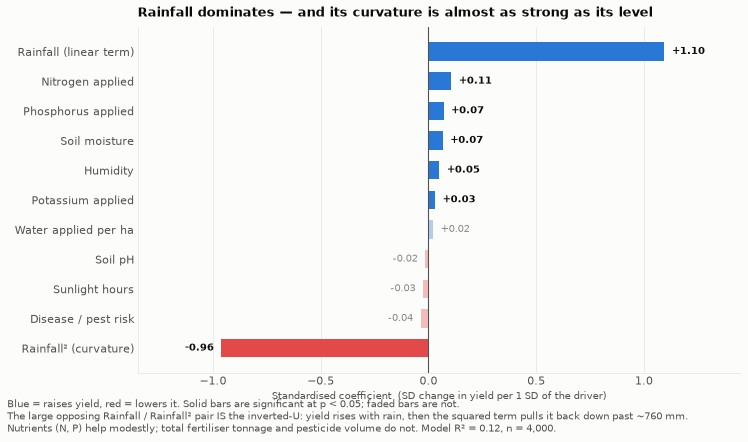

In [39]:
plot_df = std_res[std_res.t.abs() > 1.0].copy()
labels = {'Rainfall_mm': 'Rainfall (linear term)', 'Rain2': 'Rainfall² (curvature)',
          'Nitrogen_kg_ha': 'Nitrogen applied', 'Phosphorus_kg_ha': 'Phosphorus applied',
          'Soil_Moisture_pct': 'Soil moisture', 'Humidity_pct': 'Humidity',
          'Potassium_kg_ha': 'Potassium applied', 'Water_per_Ha': 'Water applied per ha',
          'Sunlight_Hours_Day': 'Sunlight hours', 'Soil_pH': 'Soil pH',
          'Disease_Pest_Risk_pct': 'Disease / pest risk', 'Pesticide_Litre_ha': 'Pesticide applied',
          'Fertilizer_kg_ha': 'Fertiliser applied', 'Seed_Quality_Score': 'Seed quality',
          'Avg_Temperature_C': 'Temperature'}

fig, ax = plt.subplots(figsize=(10.4, 5.8))
cols = [ACCENT if v > 0 else NEGATIVE for v in plot_df.coef]
alph = [1.0 if s else 0.35 for s in plot_df.significant]
yy = np.arange(len(plot_df))
for i, (v, c, a) in enumerate(zip(plot_df.coef, cols, alph)):
    ax.barh(i, v, height=0.62, color=c, alpha=a, zorder=3)
    ax.text(v + (0.035 if v > 0 else -0.035), i, f'{v:+.2f}',
            va='center', ha='left' if v > 0 else 'right',
            fontsize=9.6, fontweight='bold' if plot_df.significant.iloc[i] else 'normal',
            color=INK if plot_df.significant.iloc[i] else INK_MUTED)
ax.axvline(0, color=INK_2, lw=1.1, zorder=4)
ax.set_yticks(yy)
ax.set_yticklabels([labels.get(i, i) for i in plot_df.index])
ax.set_xlabel('Standardised coefficient  (SD change in yield per 1 SD of the driver)')
ax.set_xlim(-1.35, 1.45)
ax.set_title('Rainfall dominates — and its curvature is almost as strong as its level')
fig.text(0.005, -0.045,
         'Blue = raises yield, red = lowers it. Solid bars are significant at p < 0.05; faded bars are not.\n'
         'The large opposing Rainfall / Rainfall² pair IS the inverted-U: yield rises with rain, then the '
         'squared term pulls it back down past ~760 mm.\n'
         'Nutrients (N, P) help modestly; total fertiliser tonnage and pesticide volume do not. '
         'Model R² = 0.12, n = 4,000.',
         fontsize=9.5, color=INK_2, ha='left')
style(ax, xgrid=True, ygrid=False)
fig.tight_layout()
save(fig, 'fig08_model_drivers'); plt.show()

**Finding 7 — growing conditions explain the season, not the other way round.**

* Growing conditions (R² = 0.125) explain **twice as much** yield variation as the season label alone
  (R² = 0.060). Adding season back on top gains only **+0.005** — season is largely a *proxy*.
* **41 % of the Zaid penalty** is accounted for by measurable conditions, overwhelmingly rainfall.
* The strongest pair of coefficients is `Rainfall` (+1.10) against `Rainfall²` (−0.96) — the algebraic
  signature of the inverted-U curve found in Section 8.
* Among controllable inputs, only **nitrogen** (+0.11) and **phosphorus** (+0.07) have a real positive
  effect. **Total fertiliser tonnage (−0.01) and pesticide volume (−0.02) do nothing** — nutrient
  *balance* matters, bulk application does not.

**An honest caveat on model fit.** R² = 0.12 means 88 % of farm-to-farm variation is not explained by
the recorded variables. The model is used here to *rank and sign* the drivers, which it does with
strong t-statistics (rainfall t = 16.8), not to predict any individual farm's yield.

---
# 12. Summary of statistical evidence

Every claim made in this notebook, with the test behind it.

In [40]:
def kw(col):
    H, p = stats.kruskal(*[g[col].values for _, g in df.groupby('Season', observed=True)])
    n, k = len(df), 3
    return H, p, (H - k + 1) / (n - k)          # eta-squared effect size

rows = []
for col, claim in [
    ('Rainfall_mm',                   'Rainfall differs by season'),
    ('Avg_Temperature_C',             'Temperature differs by season'),
    ('Disease_Pest_Risk_pct',         'Disease/pest risk differs by season'),
    ('Rel_Yield',                     'Crop-relative YIELD differs by season'),
    ('Water_Efficiency_t_per_1000m3', 'Water efficiency differs by season'),
    ('Profit_per_Ha',                 'Profit per hectare differs by season'),
    ('Revenue_per_Ha',                'Revenue per hectare differs by season'),
    ('Cost_per_Ha',                   'Cost per hectare differs by season'),
    ('Market_Price_INR_Tonne',        'Market price differs by season'),
    ('Fertilizer_kg_ha',              'Fertiliser use differs by season'),
    ('Water_per_Ha',                  'Water applied per ha differs by season'),
    ('Seed_Quality_Score',            'Seed quality differs by season'),
]:
    H, p, eta = kw(col)
    rows.append({'Claim tested': claim, 'Test': 'Kruskal-Wallis',
                 'Statistic': round(H, 2), 'p-value': p, 'Effect size (η²)': round(eta, 4),
                 'Conclusion': 'SUPPORTED' if p < .05 else 'not supported'})

chi2, p_chi, _, _ = stats.chi2_contingency(pd.crosstab(df.Season, df.Is_Profitable))
rows.append({'Claim tested': 'Loss-making share differs by season', 'Test': 'Chi-square',
             'Statistic': round(chi2, 2), 'p-value': p_chi,
             'Effect size (η²)': round(np.sqrt(chi2 / len(df)), 4),
             'Conclusion': 'SUPPORTED'})

evidence = pd.DataFrame(rows).sort_values('Effect size (η²)', ascending=False)
evidence['p-value'] = evidence['p-value'].apply(lambda v: f'{v:.2e}')
print(evidence.to_string(index=False))
evidence.to_csv(OUT_DIR / 'statistical_evidence.csv', index=False)

                          Claim tested           Test  Statistic   p-value  Effect size (η²)    Conclusion
            Rainfall differs by season Kruskal-Wallis  2,599.670  0.00e+00             0.650     SUPPORTED
         Temperature differs by season Kruskal-Wallis  2,385.970  0.00e+00             0.596     SUPPORTED
   Disease/pest risk differs by season Kruskal-Wallis  1,430.910 1.91e-311             0.357     SUPPORTED
   Loss-making share differs by season     Chi-square     92.650  7.62e-21             0.152     SUPPORTED
 Crop-relative YIELD differs by season Kruskal-Wallis    254.110  6.62e-56             0.063     SUPPORTED
 Revenue per hectare differs by season Kruskal-Wallis    108.250  3.12e-24             0.027     SUPPORTED
  Profit per hectare differs by season Kruskal-Wallis     97.130  8.10e-22             0.024     SUPPORTED
    Water efficiency differs by season Kruskal-Wallis     56.810  4.61e-13             0.014     SUPPORTED
        Seed quality differs by seaso

**How to read the effect sizes.** η² is the share of rank-variance explained by season.

* **Environment is where season bites hardest**: rainfall η² = 0.65, temperature 0.60, disease risk 0.36.
* **Performance is affected but by less**: yield 0.06, profit 0.03, water efficiency 0.01 — real, but
  modest, because farm-to-farm variation within a season is large.
* **Three variables are genuinely flat**: market price (p = 0.94), fertiliser use (p = 0.59) and water
  applied (p = 0.05). Nature changes between seasons; **prices and farmer behaviour do not.** That
  contrast is the practical heart of this analysis.

  saved -> figures/fig09_dashboard.png


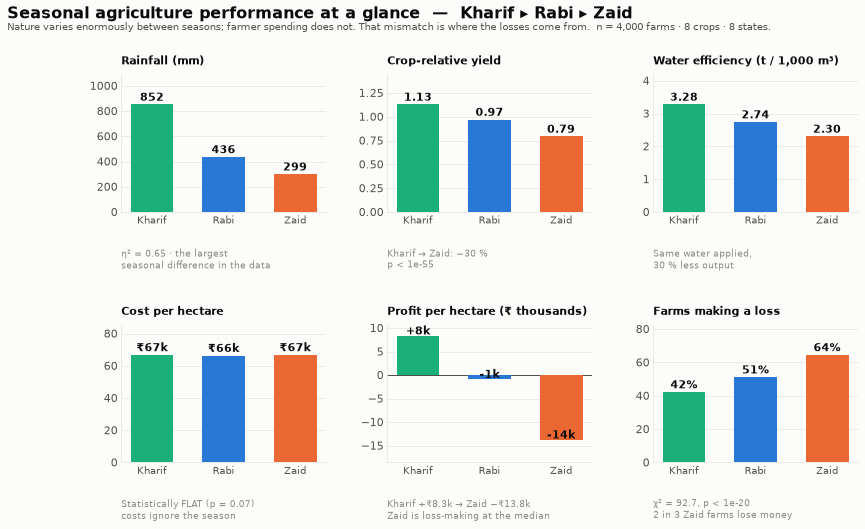

In [41]:
# One consolidated dashboard for the presentation
fig = plt.figure(figsize=(13.2, 7.0))
gs = fig.add_gridspec(2, 3, hspace=0.82, wspace=0.30)

def tile(ax, series, fmt, title, note, pct=False):
    v = series.reindex(SEASON_ORDER)
    bars = ax.bar(range(3), v, width=0.6,
                  color=[SEASON_COLOR[s] for s in SEASON_ORDER], zorder=3)
    for i, val in enumerate(v):
        ax.text(i, val + abs(v.max()) * 0.035, fmt.format(val), ha='center',
                fontsize=10.5, fontweight='bold', color=INK)
    ax.set_xticks(range(3)); ax.set_xticklabels(SEASON_ORDER, fontsize=9.5)
    ax.set_title(title, fontsize=11)
    ax.set_ylim(min(0, v.min() * 1.35), v.max() * 1.28)
    if v.min() < 0: ax.axhline(0, color=INK_2, lw=1)
    ax.text(0.0, -0.26, note, transform=ax.transAxes, fontsize=8.6, color=INK_MUTED, va='top')
    style(ax)

g = df.groupby('Season', observed=True)
tile(fig.add_subplot(gs[0, 0]), g.Rainfall_mm.mean(), '{:,.0f}',
     'Rainfall (mm)', 'η² = 0.65 · the largest\nseasonal difference in the data')
tile(fig.add_subplot(gs[0, 1]), g.Rel_Yield.median(), '{:.2f}',
     'Crop-relative yield', 'Kharif → Zaid: −30 %\np < 1e-55')
tile(fig.add_subplot(gs[0, 2]), g.Water_Efficiency_t_per_1000m3.median(), '{:.2f}',
     'Water efficiency (t / 1,000 m³)', 'Same water applied,\n30 % less output')
tile(fig.add_subplot(gs[1, 0]), g.Cost_per_Ha.median() / 1000, '₹{:,.0f}k',
     'Cost per hectare', 'Statistically FLAT (p = 0.07)\ncosts ignore the season')
tile(fig.add_subplot(gs[1, 1]), g.Profit_per_Ha.median() / 1000, '{:+,.0f}k',
     'Profit per hectare (₹ thousands)',
     'Kharif +₹8.3k → Zaid −₹13.8k\nZaid is loss-making at the median')
tile(fig.add_subplot(gs[1, 2]), (1 - g.Is_Profitable.mean()) * 100, '{:.0f}%',
     'Farms making a loss', 'χ² = 92.7, p < 1e-20\n2 in 3 Zaid farms lose money')

fig.suptitle('Seasonal agriculture performance at a glance  —  Kharif ▸ Rabi ▸ Zaid',
             fontsize=15.5, fontweight='bold', x=0.005, ha='left', y=1.015)
fig.text(0.005, 0.968,
         'Nature varies enormously between seasons; farmer spending does not. That mismatch is where '
         'the losses come from.  n = 4,000 farms · 8 crops · 8 states.',
         fontsize=10, color=INK_2, ha='left')
save(fig, 'fig09_dashboard'); plt.show()

---
# 13. Conclusions

## 13.1 The seven findings

**1. Productivity falls monotonically from monsoon to summer.**
Median crop-relative yield: **Kharif 1.13 → Rabi 0.97 → Zaid 0.79**, a 30 % drop
(Kruskal–Wallis H = 254, p < 10⁻⁵⁵; all pairwise gaps significant after Bonferroni correction).
A random Kharif farm out-yields a random Zaid farm 70 % of the time.

**2. The ranking is robust in every sub-group tested — 30 out of 30.**
Kharif > Rabi > Zaid holds in all 8 crops, all 8 states, all 10 districts and all 4 irrigation
methods. It is a property of the season, not of the data's composition.

**3. Water availability is the mechanism, and it is an inverted U.**
Yield peaks at **≈ 760 mm** of seasonal rainfall. The rainfall–yield correlation *reverses sign*
between seasons (Kharif −0.19, Rabi +0.27, Zaid +0.31) because the seasons occupy different segments
of the same curve: 62 % of Kharif farms are past the optimum, while **no Zaid farm ever reaches it**
(observed maximum 708 mm).

**4. Input behaviour is season-blind while output is not.**
Fertiliser (≈ 186 kg/ha), N-P-K, pesticide, seed quality, water applied and cost per hectare are
**statistically identical across all three seasons**. Farmers spend the same money in a season that
returns 30 % less.

**5. The profit gap is entirely a revenue problem.**
Cost per hectare (₹66.3k–₹66.7k, p = 0.07) and market price (p = 0.94) do not move. Revenue per
hectare falls ₹74.3k → ₹65.0k → ₹54.1k purely because yield falls. Loss-making farms rise from
**42 % in Kharif to 65 % in Zaid** (χ² = 92.7, p < 10⁻²⁰).

**6. Crop choice dominates season for profitability.**
Sugarcane (2.41×) and chilli (2.34×) clear break-even in every season. Wheat (0.77×), rice (0.81×)
and maize (0.85×) are **below break-even at their median yield in all three seasons** — only 8 % of
Zaid wheat farms are profitable. Season sets the slope; the crop sets the intercept.

**7. Growing conditions explain the season, not the reverse.**
Conditions explain twice the yield variation that the season label does (R² 0.125 vs 0.060); adding
season on top gains only +0.005. **41 % of the Zaid penalty** is mediated by measurable conditions.
Among controllable inputs only **nitrogen (+0.11) and phosphorus (+0.07)** matter — total fertiliser
tonnage and pesticide volume have no measurable effect.

## 13.2 The unifying insight

> **Nature varies enormously between seasons; farmer spending does not.**
> Rainfall changes by a factor of three and disease pressure by 16 points, but cost per hectare varies
> by less than 1 % and fertiliser use not at all. The seasonal losses in this dataset are not caused by
> bad weather alone — they are caused by **applying a Kharif cost structure to a Zaid growing
> environment**. That is a planning failure, and planning failures are fixable.

---

# 14. Recommendations

| # | Recommendation | Evidence | Expected effect |
|---|---|---|---|
| **R1** | **Match the cost structure to the season.** Set a lower input budget for Zaid instead of the flat ₹66.7k/ha now applied in all seasons. | Cost/ha flat (p = 0.07) while revenue/ha falls 27 % | Directly addresses the 65 % Zaid loss rate |
| **R2** | **Treat 760 mm as the water target, not a rainfall statistic.** Irrigate Rabi and Zaid *up towards* it; invest in **drainage** for the 62 % of Kharif farms already above it. | Inverted-U optimum ≈ 760 mm; ρ reverses sign by season | The only lever that moves the top of the yield curve |
| **R3** | **Shift Zaid acreage from wheat, rice and maize towards chilli and sugarcane.** | Break-even ratios 0.77–0.85 vs 2.34–2.41; Zaid wheat only 8 % profitable | Largest single profitability gain available |
| **R4** | **Expand drip irrigation, starting with Zaid.** Drip is the only method with positive median profit in Kharif *and* Rabi and the smallest Zaid loss. | Drip 2.57 t/1,000 m³ vs flood 1.41 in Zaid | Raises output per m³ where water is scarcest |
| **R5** | **Rebalance fertiliser towards nitrogen and phosphorus rather than increasing tonnage.** | N β = +0.11, P β = +0.07, both p < 0.001; total fertiliser β = −0.01 (n.s.) | Better yield at equal or lower input cost |
| **R6** | **Budget for disease control in Kharif specifically.** Kharif risk is 54 % vs 38 % in Zaid, yet pesticide use is identical across seasons. | Disease η² = 0.36; pesticide p = 0.59 | Protects the highest-yielding season |
| **R7** | **Report performance as crop-relative yield.** Raw t/ha comparisons across a mixed crop portfolio are uninterpretable — the naive ANOVA on raw yield missed a real effect (p = 0.23). | Section 6.1 | Prevents the wrong conclusion being drawn |

---

# 15. Limitations

Stated plainly, because the strength of a conclusion depends on them.

1. **No time dimension.** The dataset has no year or date column, so "seasonal trend" here means
   *differences between seasons*, never change over time. No forecasting is possible or attempted.
2. **State and District are not a real geographic hierarchy** (Section 3.5) — all 80 combinations
   occur, including impossible ones. They are used only as grouping factors for robustness testing,
   never as geography.
3. **Observational, not experimental.** Every relationship is an association. The inverted-U rainfall
   response is consistent with agronomy and holds across all sub-groups, but no causal claim is proven.
4. **Modest explanatory power.** The best model reaches R² = 0.13; 87 % of farm-to-farm variation is
   unexplained. Findings describe *group-level* tendencies, not individual predictions.
5. **Yield reconstruction and imputation.** 32 yields were reconstructed exactly from a verified
   identity (safe); 88 rainfall/soil-moisture values were median-imputed within season groups, which
   slightly compresses within-group variance.
6. **Loss rates depend on the cost model.** 51 % of all farms are loss-making, which is high for real
   Indian agriculture. Costs appear to be modelled per hectare independently of the crop, so absolute
   profit levels should be read as *relative* comparisons between seasons rather than as true margins.
7. **Unmeasured variables.** Variety, sowing date, farm mechanisation, labour and subsidies are absent —
   likely a large part of the unexplained 87 %.

---

# 16. Reproducibility

```
project/
├── data/    seasonal_agriculture_performance_dataset.csv   (input, unmodified)
├── figures/ fig01 … fig09 .png                             (charts, also used in the deck)
├── outputs/ agriculture_clean.csv, season_performance_summary.csv,
│            robustness_summary.csv, breakeven_by_crop_season.csv,
│            model_coefficients.csv, statistical_evidence.csv
└── Seasonal_Agriculture_Performance_Analysis.ipynb
```

Run top-to-bottom with `pandas`, `numpy`, `matplotlib`, `seaborn`, `scipy`. No random number
generation is used anywhere, so the notebook is fully deterministic.

In [42]:
print('=' * 78)
print('ANALYSIS COMPLETE'.center(78))
print('=' * 78)
print(f'\nRecords analysed      : {len(df):,}')
print(f'Seasons compared      : {", ".join(SEASON_ORDER)}')
print(f'Crops / states        : {df.Crop.nunique()} crops across {df.State.nunique()} states')
print(f'Figures written       : {len(sorted(FIG_DIR.glob("*.png")))} -> figures/')
print(f'Result tables written : {len(sorted(OUT_DIR.glob("*.csv")))} -> outputs/')
print('\nHeadline result')
print('-' * 78)
res = df.groupby('Season', observed=True).agg(
    rel_yield=('Rel_Yield', 'median'),
    profit_per_ha=('Profit_per_Ha', 'median'),
    loss_rate=('Is_Profitable', lambda s: (1 - s.mean()) * 100)).reindex(SEASON_ORDER)
for s in SEASON_ORDER:
    r = res.loc[s]
    print(f'  {SEASON_LABEL[s]:20s} yield index {r.rel_yield:.2f}   '
          f'profit ₹{r.profit_per_ha:>9,.0f}/ha   {r.loss_rate:.0f}% of farms lose money')
print('-' * 78)
print('  Nature varies enormously between seasons; farmer spending does not.')
print('=' * 78)

                              ANALYSIS COMPLETE                               

Records analysed      : 4,000
Seasons compared      : Kharif, Rabi, Zaid
Crops / states        : 8 crops across 8 states
Figures written       : 11 -> figures/
Result tables written : 6 -> outputs/

Headline result
------------------------------------------------------------------------------
  Kharif (monsoon)     yield index 1.13   profit ₹    8,340/ha   42% of farms lose money
  Rabi (winter)        yield index 0.97   profit ₹     -894/ha   51% of farms lose money
  Zaid (summer)        yield index 0.79   profit ₹  -13,760/ha   64% of farms lose money
------------------------------------------------------------------------------
  Nature varies enormously between seasons; farmer spending does not.
